In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from ESMCBA import other_utils
import importlib
importlib.reload(other_utils)
from pathlib import Path

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
evaluations = pd.read_csv('../evaluations_full_02062025.csv')

In [5]:
evaluations_dt_subset = evaluations
evaluations_dt_subset['rank_mse'] = evaluations_dt_subset.groupby('Model')['mse'].rank(ascending=True)
evaluations_dt_subset['rank_corr'] = evaluations_dt_subset.groupby('Model')['spearman'].rank(ascending=False)

# 2. Sum the ranks or any other combination you want.
evaluations_dt_subset['rank_sum'] = evaluations_dt_subset['rank_mse'] + evaluations_dt_subset['rank_corr']

# 3. Sort by rank_sum and pick the best model for each Model.
ranked_per_Model = (
    evaluations
    .sort_values('rank_sum', ascending=True)
    .drop_duplicates(subset='Model', keep='first')  
)

# ranked_per_Model = ranked_per_Model[ranked_per_Model['Model'].apply(len) == 8] 

In [6]:
evaluations_dt_sorted = ranked_per_Model[
                                         (ranked_per_Model['spearman'] > -0.01)
                                          ].sort_values(by=['spearman'], ascending = [False])#.drop_duplicates('Model') #[evaluations_dt['Losses'] == 'MSE']

In [7]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:

    if '0206' in allele:
        print(allele)

    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)

    if epitope_data[epitope_data["Year_submission"] < 2019].empty:
        epitope_data = epitope_data[epitope_data["Year_submission"] > 1995]
    else:
        epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

metrics_df = metrics_df.sort_values(by=['HLA', 'encoding'])# .#head(50)
# metrics_df÷

A0206 epitope
A0206 HLA
All test datasets were empty for HLA C0701 HLA. Skipping this allele.


In [8]:
evaluations['pretrain'] = evaluations['path'].str.contains('False')
evaluations['pretrain'] = evaluations['pretrain'].astype(bool)
evaluations['pretrain'] = evaluations['pretrain'].replace({True: 'Not Pretrained', False: 'Pretrained'})

In [9]:
evaluations_dt_plot = pd.merge(left=metrics_df[['HLA','training_data']], right= evaluations,on= 'HLA', how='right') #.sort_values(by='spearman', ascending =False)

In [10]:
# Step 1: Bin sizes
bins = [0, 500, 1000, 2000, 4000, np.inf]
labels = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
evaluations_dt_plot['size_bin'] = pd.cut(evaluations_dt_plot['training_data'].astype('float'), bins=bins, labels=labels)

# Step 2: Aggregate means and SEM
agg = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
    .groupby(['size_bin', 'encoding', 'pretrain','trained_blocks'])['spearman']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
agg['sem'] = agg['std'] / np.sqrt(agg['count'])

# Step 3: Build one label for each bar
agg['group_label'] =  agg['pretrain'] + ' ' + agg['encoding'] + ' ' + agg['trained_blocks'].astype('str') + ' Finetuned Layers' #.map({True: 'Pre-trained', False: 'Not pre-trained'})


/tmp/ipykernel_3518588/2086353431.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_bin', 'encoding', 'pretrain','trained_blocks'])['spearman']


In [11]:
evaluations_dt_plot = pd.merge(left=metrics_df[['HLA','training_data']], right= evaluations,on= 'HLA', how='right')
evaluations_dt_plot['training_data'] = evaluations_dt_plot['training_data'].astype(float) * evaluations_dt_plot['data_prop'].astype(float)


# Step 1: Bin sizes
bins = [0, 500, 1000, 2000, 4000, np.inf]
labels = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
evaluations_dt_plot['size_bin'] = pd.cut(evaluations_dt_plot['training_data'].astype('float'), bins=bins, labels=labels)


evaluations_dt_plot['spearman'] = evaluations_dt_plot['spearman'].astype(float)
evaluations_dt_plot['size_bin'] = evaluations_dt_plot['size_bin'].astype(str)

evaluations_dt_plot['group_label'] = (
    evaluations_dt_plot['pretrain'].map({'Pretrained': 'PT', 'Not Pretrained': 'Non-PT'}) + ' ' +
    evaluations_dt_plot['encoding'].map({'HLA': 'H', 'epitope': 'E'}) + ' ' +
    evaluations_dt_plot['trained_blocks'].map({0: '0L', 30: '30L'})
)


In [12]:
# same aggregation you already had …
stats = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean')
      .reset_index()
)

stats

,size_bin,group_label,count,mean
0,1000–2000,Non-PT E 0L,114,0.237168
1,1000–2000,Non-PT E 30L,116,0.459185
2,1000–2000,Non-PT H 0L,168,0.012957
3,1000–2000,Non-PT H 30L,132,0.525028
4,1000–2000,PT E 0L,166,0.247023
5,1000–2000,PT E 30L,198,0.496661
6,1000–2000,PT H 0L,152,0.025456
7,1000–2000,PT H 30L,124,0.442668
8,2000–4000,Non-PT E 0L,106,0.336809
9,2000–4000,Non-PT E 30L,108,0.556623


In [13]:
# same aggregation you already had …
stats = (
    evaluations_dt_plot[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['pearsonr']
      .agg(count  ='size',
           mean   ='mean')
      .reset_index()
)

stats

,size_bin,group_label,count,mean
0,1000–2000,Non-PT E 0L,114,0.263316
1,1000–2000,Non-PT E 30L,116,0.516684
2,1000–2000,Non-PT H 0L,168,0.046976
3,1000–2000,Non-PT H 30L,132,0.565711
4,1000–2000,PT E 0L,166,0.312647
5,1000–2000,PT E 30L,198,0.536533
6,1000–2000,PT H 0L,152,-0.007155
7,1000–2000,PT H 30L,124,0.502174
8,2000–4000,Non-PT E 0L,106,0.356562
9,2000–4000,Non-PT E 30L,108,0.616842


In [14]:
evaluations_dt_plot2 = evaluations_dt_plot[evaluations_dt_plot['n_evaluations'] > 100]

from scipy.stats import t              # Student-t for the CI

# same aggregation you already had …
stats = (
    evaluations_dt_plot2 #[evaluations_dt_plot['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats

,size_bin,group_label,count,mean,ci_low,ci_high
0,1000–2000,Non-PT E 0L,36,0.231134,0.194601,0.267667
1,1000–2000,Non-PT E 30L,36,0.461521,0.422930,0.500111
2,1000–2000,Non-PT H 0L,52,0.100802,0.056260,0.145344
3,1000–2000,Non-PT H 30L,40,0.486746,0.444716,0.528776
4,1000–2000,PT E 0L,50,0.233327,0.207258,0.259395
5,1000–2000,PT E 30L,62,0.484849,0.453337,0.516361
6,1000–2000,PT H 0L,48,0.065849,0.003774,0.127923
7,1000–2000,PT H 30L,36,0.464389,0.385230,0.543549
8,2000–4000,Non-PT E 0L,48,0.309728,0.271146,0.348310
9,2000–4000,Non-PT E 30L,48,0.576603,0.546638,0.606569


In [15]:
stats = (
    evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['spearman']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats.T

stats = (
    evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
      .groupby(['size_bin', 'group_label'])['pearsonr']
      .agg(count  ='size',
           mean   ='mean',
           std    ='std')
      .reset_index()
)

# standard error
stats['sem'] = stats['std'] / np.sqrt(stats['count'])

# 95 % CI for the mean:  mean ± t_(α/2, df) * sem
alpha  = 0.05
stats['ci_low']  = stats['mean'] - t.ppf(1-alpha/2, stats['count']-1) * stats['sem']
stats['ci_high'] = stats['mean'] + t.ppf(1-alpha/2, stats['count']-1) * stats['sem']

# Optional: round or re-order columns
stats = stats[['size_bin','group_label','count','mean','ci_low','ci_high']]
stats.T


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
size_bin,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,1000–2000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,2000–4000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,500–1000,<500,<500,<500,<500,<500,<500,<500,<500,>4000,>4000,>4000,>4000,>4000,>4000,>4000,>4000,nan,nan,nan,nan,nan,nan,nan,nan
group_label,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L,Non-PT E 0L,Non-PT E 30L,Non-PT H 0L,Non-PT H 30L,PT E 0L,PT E 30L,PT H 0L,PT H 30L
count,36,36,52,40,50,62,48,36,48,48,64,58,70,82,70,68,16,16,20,24,28,32,26,20,8,8,10,12,16,14,10,6,32,32,38,32,30,52,30,38,14,14,19,18,19,25,19,22
mean,0.235213,0.455026,0.111671,0.47443,0.23356,0.476168,0.050435,0.464523,0.31163,0.577222,0.179622,0.577948,0.290757,0.572197,0.114152,0.591282,0.320858,0.409135,0.064988,0.393221,0.163607,0.461745,0.061877,0.363725,0.176416,0.291177,0.001461,0.292487,0.150797,0.281335,0.206553,0.150166,0.258499,0.561205,0.210814,0.586075,0.362422,0.586271,0.19838,0.57118,0.393559,0.766107,0.340622,0.77524,0.418716,0.757843,0.213151,0.746172
ci_low,0.194429,0.413781,0.063548,0.423628,0.204034,0.439569,-0.012957,0.381956,0.271611,0.54394,0.124958,0.540128,0.264249,0.544442,0.062701,0.55534,0.247261,0.346606,-0.056233,0.317854,0.103865,0.415021,-0.025542,0.271081,0.122544,0.241445,-0.049912,0.218137,0.123706,0.252081,0.14644,0.120349,0.208365,0.530864,0.190722,0.545583,0.341919,0.558669,0.150827,0.531688,0.34622,0.724877,0.299891,0.736141,0.385884,0.723837,0.166359,0.702293
ci_high,0.275997,0.49627,0.159793,0.525232,0.263086,0.512767,0.113828,0.547091,0.351649,0.610504,0.234285,0.615769,0.317266,0.599951,0.165602,0.627224,0.394456,0.471664,0.186208,0.468588,0.223349,0.508469,0.149296,0.456368,0.230288,0.340908,0.052834,0.366837,0.177889,0.310588,0.266666,0.179983,0.308632,0.591545,0.230906,0.626568,0.382926,0.613873,0.245934,0.610671,0.440898,0.807337,0.381352,0.814338,0.451548,0.791848,0.259942,0.790051


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import t

def generate_correlation_table(evaluations_dt_plot2):
    """
    Generate a formatted table with Spearman and Pearson correlations
    organized by model and training set size, including confidence intervals.
    """
    
    # Calculate Spearman statistics
    spearman_stats = (
        evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
        .groupby(['size_bin', 'group_label'])['spearman']
        .agg(count='size', mean='mean', std='std')
        .reset_index()
    )
    
    # Add confidence intervals for Spearman
    spearman_stats['sem'] = spearman_stats['std'] / np.sqrt(spearman_stats['count'])
    alpha = 0.05
    spearman_stats['ci_low'] = spearman_stats['mean'] - t.ppf(1-alpha/2, spearman_stats['count']-1) * spearman_stats['sem']
    spearman_stats['ci_high'] = spearman_stats['mean'] + t.ppf(1-alpha/2, spearman_stats['count']-1) * spearman_stats['sem']
    
    # Calculate Pearson statistics
    pearson_stats = (
        evaluations_dt_plot2[evaluations_dt_plot2['spearman'] != 0]
        .groupby(['size_bin', 'group_label'])['pearsonr']
        .agg(count='size', mean='mean', std='std')
        .reset_index()
    )
    
    # Add confidence intervals for Pearson
    pearson_stats['sem'] = pearson_stats['std'] / np.sqrt(pearson_stats['count'])
    pearson_stats['ci_low'] = pearson_stats['mean'] - t.ppf(1-alpha/2, pearson_stats['count']-1) * pearson_stats['sem']
    pearson_stats['ci_high'] = pearson_stats['mean'] + t.ppf(1-alpha/2, pearson_stats['count']-1) * pearson_stats['sem']
    
    # Define the order of size bins and models for consistent formatting
    size_order = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
    model_order = ['Non-PT E 0L', 'Non-PT E 30L', 'PT E 0L', 'PT E 30L', 
                   'Non-PT H 0L', 'Non-PT H 30L', 'PT H 0L', 'PT H 30L']
    
    # Create pivot tables for easier table generation
    spearman_pivot = spearman_stats.pivot(index='group_label', columns='size_bin', values='mean')
    pearson_pivot = pearson_stats.pivot(index='group_label', columns='size_bin', values='mean')
    
    # Create CI pivot tables
    spearman_ci_low = spearman_stats.pivot(index='group_label', columns='size_bin', values='ci_low')
    spearman_ci_high = spearman_stats.pivot(index='group_label', columns='size_bin', values='ci_high')
    pearson_ci_low = pearson_stats.pivot(index='group_label', columns='size_bin', values='ci_low')
    pearson_ci_high = pearson_stats.pivot(index='group_label', columns='size_bin', values='ci_high')
    
    # Reorder columns and rows
    spearman_pivot = spearman_pivot.reindex(index=model_order, columns=size_order)
    pearson_pivot = pearson_pivot.reindex(index=model_order, columns=size_order)
    spearman_ci_low = spearman_ci_low.reindex(index=model_order, columns=size_order)
    spearman_ci_high = spearman_ci_high.reindex(index=model_order, columns=size_order)
    pearson_ci_low = pearson_ci_low.reindex(index=model_order, columns=size_order)
    pearson_ci_high = pearson_ci_high.reindex(index=model_order, columns=size_order)
    
    # Generate LaTeX table with confidence intervals
    latex_table = generate_latex_table_with_ci(spearman_pivot, pearson_pivot, 
                                              spearman_ci_low, spearman_ci_high,
                                              pearson_ci_low, pearson_ci_high)
    
    # Generate pandas-style table for display with confidence intervals
    combined_table = generate_combined_dataframe_with_ci(spearman_pivot, pearson_pivot,
                                                        spearman_ci_low, spearman_ci_high,
                                                        pearson_ci_low, pearson_ci_high)
    
    return {
        'spearman_stats': spearman_stats,
        'pearson_stats': pearson_stats,
        'latex_table': latex_table,
        'combined_table': combined_table
    }

def generate_latex_table_with_ci(spearman_pivot, pearson_pivot, 
                                spearman_ci_low, spearman_ci_high,
                                pearson_ci_low, pearson_ci_high):
    """Generate LaTeX table format with confidence intervals as ± values, split into multiple tables by size categories"""
    
    # Split size categories into groups to fit page width
    size_groups = [
        (['<500', '500–1000'], 'small'),
        (['1000–2000', '2000–4000'], 'medium'), 
        (['>4000'], 'large')
    ]
    
    tables = {}
    
    for size_bins, group_name in size_groups:
        # Determine number of columns needed
        num_cols = len(size_bins) * 2 + 1  # +1 for model name column
        
        latex = f"""\\begin{{table}}[ht]
  \\centering
  \\small
\\caption{{Mean Spearman $\\rho$ and Pearson $r$ by model selection and training-set size with 95\\% confidence intervals - {group_name.title()} training sets.}}
\\label{{tab:mean_correlations_{group_name}}}
\\begin{{tabular}}{{'l' + 'cc' * len(size_bins)}}
\\toprule
 & \\multicolumn{{{len(size_bins) * 2}}}{{c}}{{Size of Binding Affinity Training Data (Peptides)}} \\\\
\\midrule"""
        
        # Add size bin headers
        size_header = " & "
        for size_bin in size_bins:
            size_header += f"\\multicolumn{{2}}{{c}}{{\\textbf{{{size_bin}}}}} & "
        size_header = size_header.rstrip(" & ") + " \\\\\n"
        latex += size_header
        
        # Add correlation type headers
        corr_header = "\\textbf{Model} "
        for _ in size_bins:
            corr_header += "& \\boldmath$\\rho$ & \\boldmath$r$ "
        corr_header += "\\\\\n\\midrule\n"
        latex += corr_header
        
        # Add E models section
        latex += "\\multicolumn{" + str(num_cols) + "}{l}{\\textbf{\\textsc{ESMCBA\\textsubscript{E}} (E) Models}} \\\\\n"
        
        e_models = ['Non-PT E 0L', 'Non-PT E 30L', 'PT E 0L', 'PT E 30L']
        for model in e_models:
            if model in spearman_pivot.index:
                row = f"{model.replace('Non-PT E ', 'Non-PT E ').replace('PT E ', 'PT E ')} "
                for size_bin in size_bins:
                    spearman_val = spearman_pivot.loc[model, size_bin]
                    pearson_val = pearson_pivot.loc[model, size_bin]
                    spearman_low = spearman_ci_low.loc[model, size_bin]
                    spearman_high = spearman_ci_high.loc[model, size_bin]
                    pearson_low = pearson_ci_low.loc[model, size_bin]
                    pearson_high = pearson_ci_high.loc[model, size_bin]
                    
                    if pd.notna(spearman_val) and pd.notna(pearson_val):
                        spearman_margin = (spearman_high - spearman_low) / 2
                        pearson_margin = (pearson_high - pearson_low) / 2
                        row += f"& {spearman_val:.3f} $\\pm$ {spearman_margin:.3f} & {pearson_val:.3f} $\\pm$ {pearson_margin:.3f} "
                    else:
                        row += "& -- & -- "
                row += "\\\\\n"
                latex += row
        
        # Add H models section
        latex += "\\midrule\n"
        latex += "\\multicolumn{" + str(num_cols) + "}{l}{\\textbf{\\textsc{ESMCBA\\textsubscript{HLA+E}} (H) Models}} \\\\\n"
        
        h_models = ['Non-PT H 0L', 'Non-PT H 30L', 'PT H 0L', 'PT H 30L']
        for model in h_models:
            if model in spearman_pivot.index:
                row = f"{model.replace('Non-PT H ', 'Non-PT H ').replace('PT H ', 'PT H ')} "
                for size_bin in size_bins:
                    spearman_val = spearman_pivot.loc[model, size_bin]
                    pearson_val = pearson_pivot.loc[model, size_bin]
                    spearman_low = spearman_ci_low.loc[model, size_bin]
                    spearman_high = spearman_ci_high.loc[model, size_bin]
                    pearson_low = pearson_ci_low.loc[model, size_bin]
                    pearson_high = pearson_ci_high.loc[model, size_bin]
                    
                    if pd.notna(spearman_val) and pd.notna(pearson_val):
                        spearman_margin = (spearman_high - spearman_low) / 2
                        pearson_margin = (pearson_high - pearson_low) / 2
                        row += f"& {spearman_val:.3f} $\\pm$ {spearman_margin:.3f} & {pearson_val:.3f} $\\pm$ {pearson_margin:.3f} "
                    else:
                        row += "& -- & -- "
                row += "\\\\\n"
                latex += row
        
        latex += """\\bottomrule
\\end{tabular}
\\end{table}

"""
        
        tables[group_name] = latex
    
    return tables

def generate_combined_dataframe_with_ci(spearman_pivot, pearson_pivot,
                                       spearman_ci_low, spearman_ci_high,
                                       pearson_ci_low, pearson_ci_high):
    """Generate combined DataFrames for easy viewing with confidence intervals as ± values, split by size groups"""
    
    # Split size categories into groups
    size_groups = [
        (['<500', '500–1000'], 'small'),
        (['1000–2000', '2000–4000'], 'medium'), 
        (['>4000'], 'large')
    ]
    
    dataframes = {}
    
    for size_bins, group_name in size_groups:
        # Create multi-level columns for this group
        col_tuples = []
        for size_bin in size_bins:
            col_tuples.extend([(size_bin, 'ρ (±)'), (size_bin, 'r (±)')])
        
        # All models together
        all_models = ['Non-PT E 0L', 'Non-PT E 30L', 'PT E 0L', 'PT E 30L',
                      'Non-PT H 0L', 'Non-PT H 30L', 'PT H 0L', 'PT H 30L']
        
        combined_data = []
        for model in all_models:
            if model in spearman_pivot.index:
                row = []
                for size_bin in size_bins:
                    spearman_val = spearman_pivot.loc[model, size_bin]
                    pearson_val = pearson_pivot.loc[model, size_bin]
                    spearman_low = spearman_ci_low.loc[model, size_bin]
                    spearman_high = spearman_ci_high.loc[model, size_bin]
                    pearson_low = pearson_ci_low.loc[model, size_bin]
                    pearson_high = pearson_ci_high.loc[model, size_bin]
                    
                    if pd.notna(spearman_val) and pd.notna(pearson_val):
                        spearman_margin = (spearman_high - spearman_low) / 2
                        pearson_margin = (pearson_high - pearson_low) / 2
                        spearman_str = f"{spearman_val:.3f} ± {spearman_margin:.3f}"
                        pearson_str = f"{pearson_val:.3f} ± {pearson_margin:.3f}"
                    else:
                        spearman_str = "--"
                        pearson_str = "--"
                    
                    row.extend([spearman_str, pearson_str])
                combined_data.append(row)
        
        df = pd.DataFrame(combined_data, 
                         index=[m for m in all_models if m in spearman_pivot.index],
                         columns=pd.MultiIndex.from_tuples(col_tuples))
        
        dataframes[group_name] = df
    
    return dataframes

# # Example usage:
# results = generate_correlation_table(pd.concat([evaluations_dt_plot[(evaluations_dt_plot['path'].str.contains('False'))],
#  df]))
# print("LaTeX Table for E Models:")
# print(results['latex_table']['small'])
# print(results['latex_table']['medium'])
# print(results['latex_table']['large'])
# print("\nLaTeX Table for H Models:")
# print(results['latex_table']['h_models'])
# print("\nE Models DataFrame:")
# print(results['combined_table']['s'])
# print("\nH Models DataFrame:")
# print(results['combined_table']['h_models'])

# To display statistics with confidence intervals:
# print("\nSpearman Statistics:")
# print(results['spearman_stats'][['size_bin', 'group_label', 'mean', 'ci_low', 'ci_high']])
# print("\nPearson Statistics:")  
# print(results['pearson_stats'][['size_bin', 'group_label', 'mean', 'ci_low', 'ci_high']])

In [17]:
# counts per (HLA, group_label, data_prop)
triple_counts = (
    evaluations_dt_plot.drop_duplicates('spearman')
      .groupby(['HLA', 'group_label', 'data_prop'])
      .size()
      .reset_index(name='n_rows')
)

# keep triples with ≥3 rows
triples_ge3 = triple_counts.query('n_rows >= 3')[['HLA', 'group_label', 'data_prop']]

# subset the original data to only those triples
subset = evaluations_dt_plot.drop_duplicates('spearman').merge(triples_ge3, on=['HLA', 'group_label', 'data_prop'])


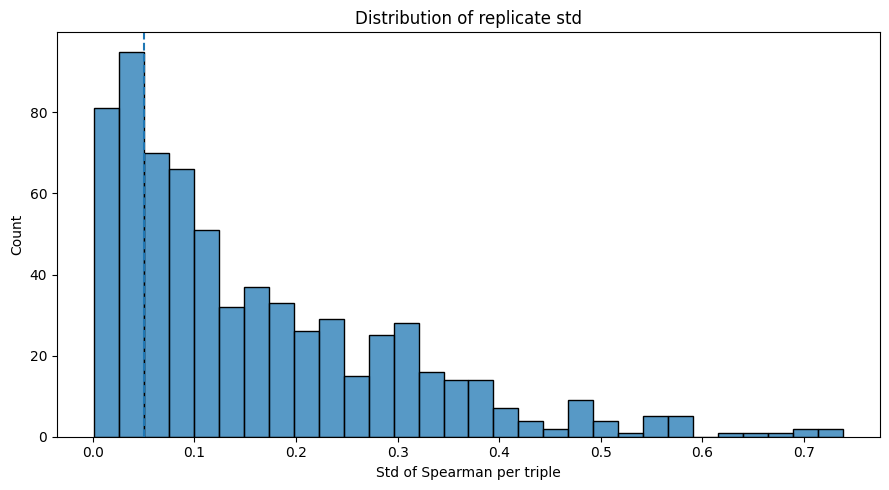

/tmp/ipykernel_3518588/2655267836.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


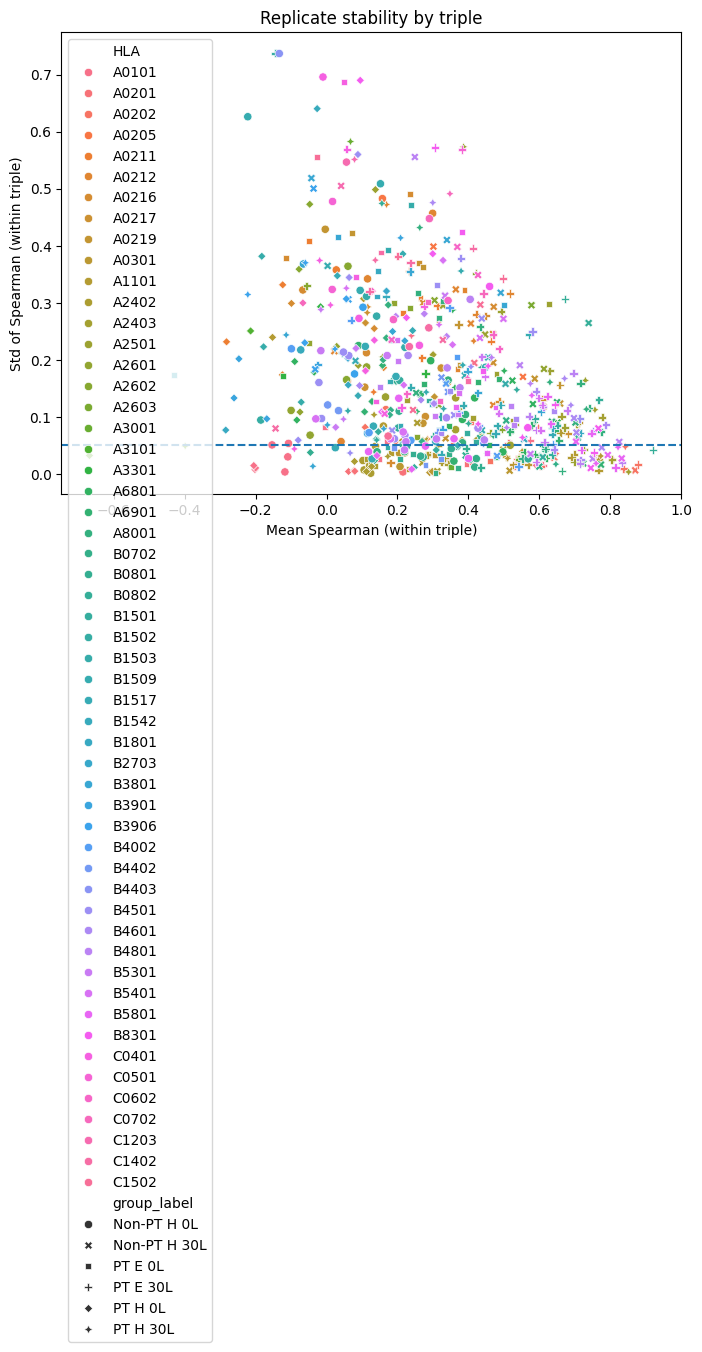

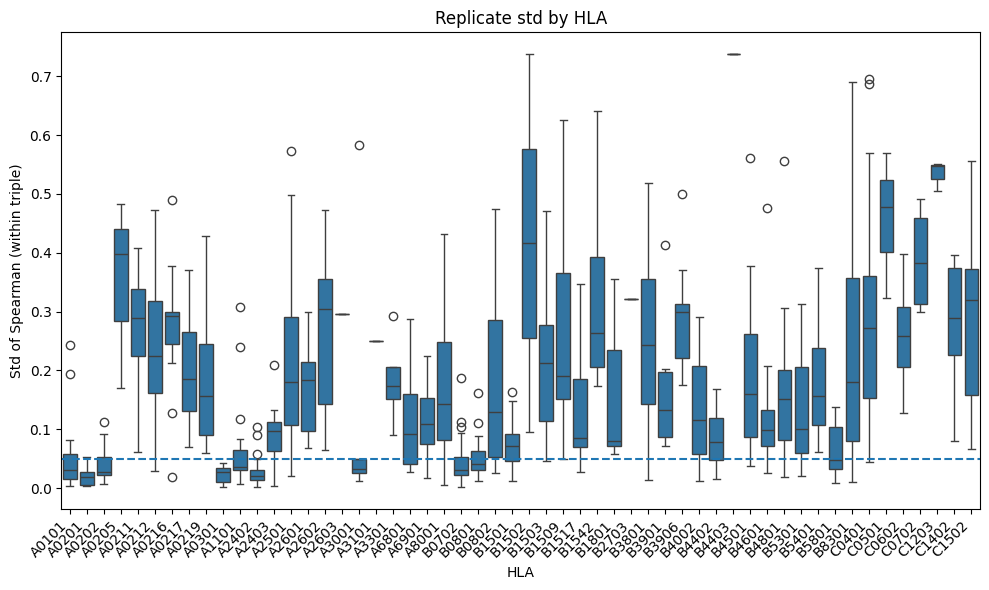

In [18]:
df = subset.copy()  # or subset_strict if you used that name

# 1) Replicate stats per (HLA, group_label, data_prop)
rep_stats = (
    df.groupby(['HLA', 'group_label', 'data_prop'])['spearman']
      .agg(n_reps='size', mean='mean', std='std')
      .reset_index()
)
rep_stats['std'] = rep_stats['std'].fillna(0.0)

# 2) Keep only low-variance triples (tune the threshold as needed)
STD_THRESH = 0.05
low_var_triples  = rep_stats.query('std <= @STD_THRESH')[['HLA','group_label','data_prop']]
high_var_triples = rep_stats.query('std >  @STD_THRESH')[['HLA','group_label','data_prop']]

subset_lowvar = df.merge(low_var_triples, on=['HLA','group_label','data_prop'])
# If you want to drop high-variance triples entirely, work with subset_lowvar from here on.

# 3) Plots

# 3a) Histogram of std across triples
plt.figure(figsize=(9,5))
sns.histplot(rep_stats['std'], bins=30)
plt.axvline(STD_THRESH, ls='--')
plt.xlabel('Std of Spearman per triple')
plt.ylabel('Count')
plt.title('Distribution of replicate std')
plt.tight_layout()
plt.show()

# 3b) Mean vs std, colored by HLA, shaped by group_label
plt.figure(figsize=(8,6))
sns.scatterplot(data=rep_stats, x='mean', y='std', hue='HLA', style='group_label')
plt.axhline(STD_THRESH, ls='--')
plt.xlabel('Mean Spearman (within triple)')
plt.ylabel('Std of Spearman (within triple)')
plt.title('Replicate stability by triple')
plt.tight_layout()
plt.show()

# 3c) Boxplot of std by HLA (flip to group_label if you prefer)
plt.figure(figsize=(10,6))
sns.boxplot(data=rep_stats, x='HLA', y='std')
plt.axhline(STD_THRESH, ls='--')
plt.ylabel('Std of Spearman (within triple)')
plt.title('Replicate std by HLA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

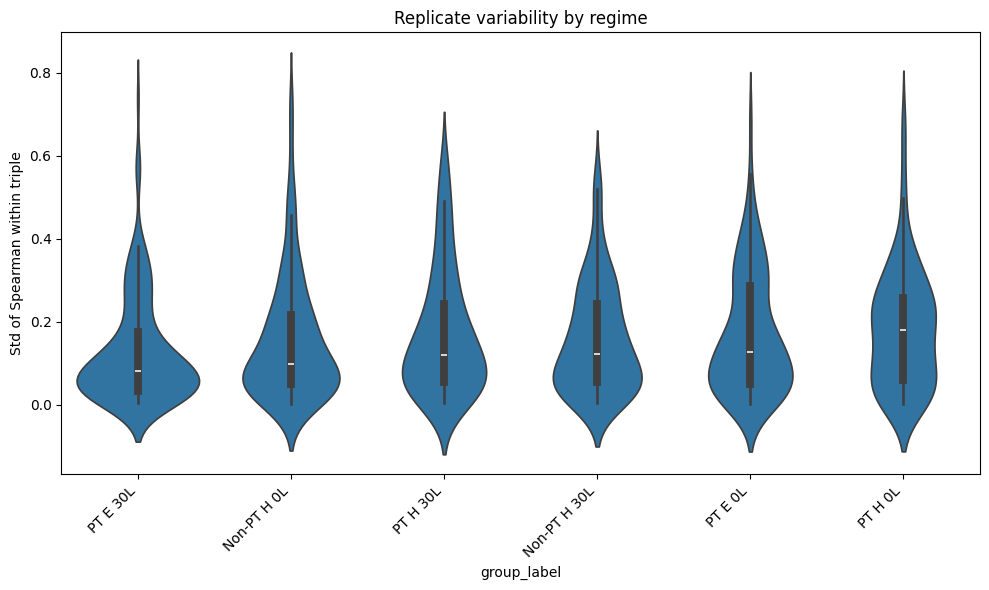

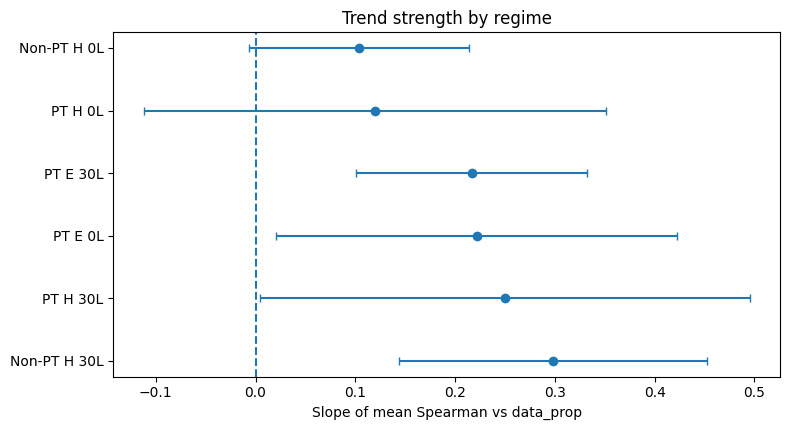

Fligner-Killeen across all regimes: stat=14.510, p=0.0127


,group_label,n_triples,median_std,iqr_std,p95_std,median_mean,iqr_mean
0,PT E 30L,158,0.080976,0.140219,0.358044,0.563840,0.241815
1,Non-PT H 0L,132,0.099631,0.166564,0.466489,0.199047,0.226188
2,PT H 30L,85,0.120732,0.187971,0.475560,0.379388,0.437252
3,Non-PT H 30L,98,0.121850,0.186814,0.400478,0.470100,0.287675
4,PT E 0L,103,0.127205,0.235809,0.422330,0.297640,0.193112
5,PT H 0L,100,0.179714,0.197803,0.390489,0.109768,0.261686


,group_label,slope,slope_lo,slope_hi,n_points
1,Non-PT H 30L,0.298055,0.143961,0.452148,98
5,PT H 30L,0.249839,0.004429,0.495250,85
2,PT E 0L,0.221602,0.020426,0.422777,103
3,PT E 30L,0.216762,0.101159,0.332366,158
4,PT H 0L,0.119774,-0.111980,0.351528,100
0,Non-PT H 0L,0.104064,-0.006205,0.214334,132


,group_a,group_b,stat,p,p_holm
12,PT E 30L,PT H 0L,9.217792,0.002397,0.035951
9,PT E 0L,PT E 30L,8.274255,0.004021,0.056296
13,PT E 30L,PT H 30L,7.439810,0.006380,0.082936
6,Non-PT H 30L,PT E 30L,5.659032,0.017366,0.208388
2,Non-PT H 0L,PT E 30L,4.614082,0.031710,0.348815
0,Non-PT H 0L,Non-PT H 30L,0.394550,0.529918,1.000000
1,Non-PT H 0L,PT E 0L,1.170889,0.279219,1.000000
3,Non-PT H 0L,PT H 0L,2.261860,0.132595,1.000000
4,Non-PT H 0L,PT H 30L,0.611678,0.434157,1.000000
5,Non-PT H 30L,PT E 0L,0.373000,0.541374,1.000000


In [19]:
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import fligner
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

# 0) start from your filtered triples
df = subset.copy()  # or subset_strict

# 1) replicate stats per triple
rep_stats = (
    df.groupby(['HLA','group_label','data_prop'])['spearman']
      .agg(n_reps='size', mean='mean', std='std')
      .reset_index()
)
rep_stats['std'] = rep_stats['std'].fillna(0.0)

# 2) regime-level variability summary
def IQR(x): return x.quantile(0.75) - x.quantile(0.25)
regime_var = (
    rep_stats.groupby('group_label')
      .agg(n_triples=('std','size'),
           median_std=('std','median'),
           iqr_std=('std', IQR),
           p95_std=('std', lambda s: s.quantile(0.95)),
           median_mean=('mean','median'),
           iqr_mean=('mean', IQR))
      .sort_values('median_std')
      .reset_index()
)

# 3) do regimes differ in variability?
groups = [rep_stats.loc[rep_stats.group_label==g,'std'].dropna()
          for g in rep_stats['group_label'].unique()]
fligner_all = fligner(*groups)  # robust variance test across regimes

# pairwise robust variance tests with Holm correction
pair_rows, pvals = [], []
for a,b in combinations(sorted(rep_stats['group_label'].unique()), 2):
    stat, p = fligner(rep_stats.loc[rep_stats.group_label==a,'std'],
                      rep_stats.loc[rep_stats.group_label==b,'std'])
    pair_rows.append((a,b,stat,p)); pvals.append(p)
padj = multipletests(pvals, method='holm')[1]
pairwise_var = pd.DataFrame([(a,b,stat,p,pa) for (a,b,stat,p),pa in zip(pair_rows,padj)],
                            columns=['group_a','group_b','stat','p','p_holm'])

# 4) quantify trend vs data_prop per regime using slopes on triple means
def coerce_float(x):
    # handles "0.2" or "20%" strings
    x = pd.to_numeric(x.astype(str).str.rstrip('%'), errors='coerce')
    return x if rep_stats['data_prop'].dtype.kind in 'if' else x/100.0 if x.max()>1 else x

slopes = []
for g, sub in rep_stats.groupby('group_label'):
    x = coerce_float(sub['data_prop'])
    y = sub['mean']
    ok = (~x.isna()) & (~y.isna())
    if ok.sum() >= 3 and x[ok].nunique() >= 3:
        X = sm.add_constant(x[ok].values)
        model = sm.OLS(y[ok].values, X).fit()
        slope = model.params[1]
        lo, hi = model.conf_int(alpha=0.05)[1]  # 95% CI for slope
        slopes.append({'group_label': g, 'slope': slope, 'slope_lo': lo, 'slope_hi': hi,
                       'n_points': int(ok.sum())})
slopes_df = pd.DataFrame(slopes).sort_values('slope', ascending=False)

# 5) plots
# 5a) variability by regime
order = regime_var['group_label']  # sorted by median_std
plt.figure(figsize=(10,6))
sns.violinplot(data=rep_stats, x='group_label', y='std', order=order, inner='box')
plt.xticks(rotation=45, ha='right'); plt.ylabel('Std of Spearman within triple')
plt.title('Replicate variability by regime'); plt.tight_layout(); plt.show()

# 5b) slope forest plot per regime
plt.figure(figsize=(8,0.4*len(slopes_df)+2))
ypos = np.arange(len(slopes_df))
plt.errorbar(slopes_df['slope'], ypos,
             xerr=[slopes_df['slope']-slopes_df['slope_lo'],
                   slopes_df['slope_hi']-slopes_df['slope']],
             fmt='o', capsize=3)
plt.yticks(ypos, slopes_df['group_label'])
plt.axvline(0, ls='--'); plt.xlabel('Slope of mean Spearman vs data_prop')
plt.title('Trend strength by regime'); plt.tight_layout(); plt.show()

# 6) compact tables you can print or export
print('Fligner-Killeen across all regimes: stat=%.3f, p=%.3g' % (fligner_all.statistic, fligner_all.pvalue))
display(regime_var.head(20))
display(slopes_df)
display(pairwise_var.sort_values('p_holm').head(20))


/tmp/ipykernel_3518588/1011100964.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci).reset_index())


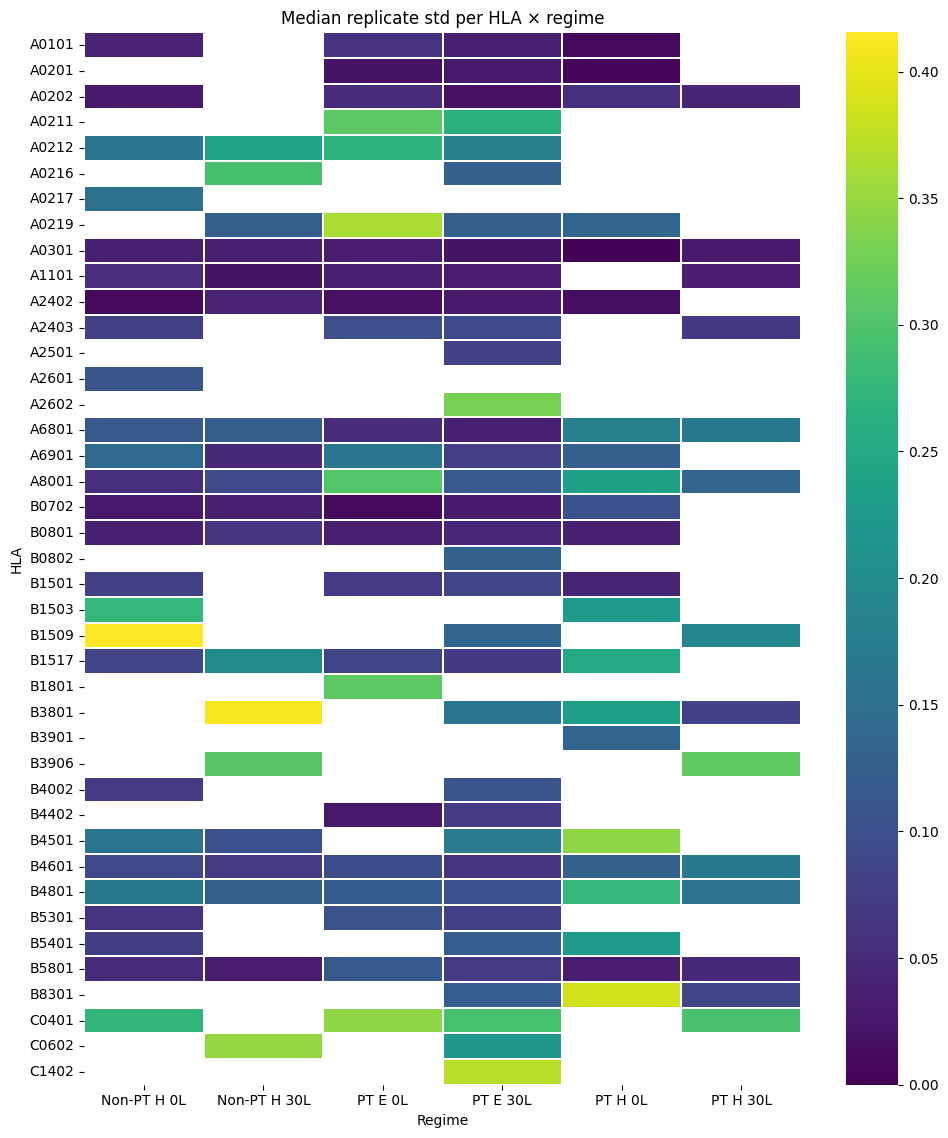

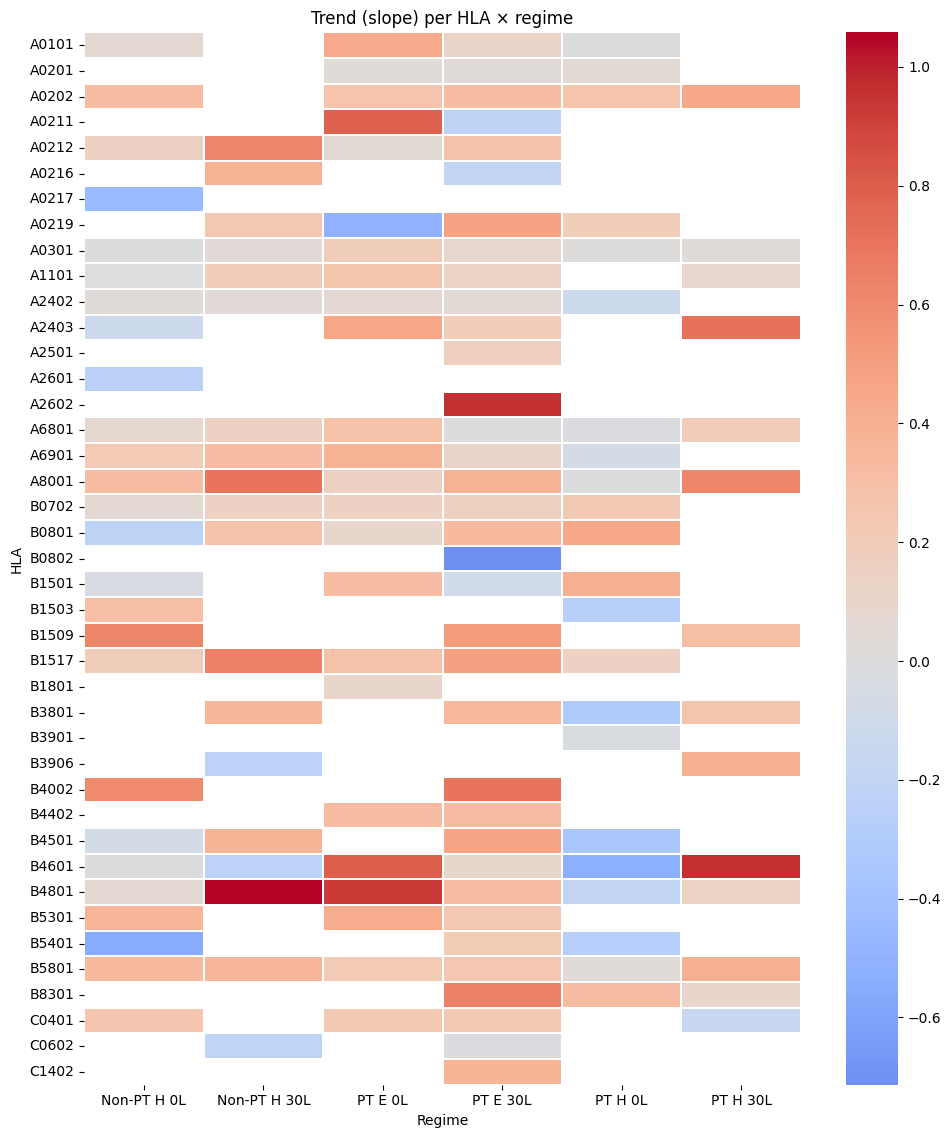

 group_label   HLA  n_triples  median_std  p95_std  median_mean     slope  slope_sig
 Non-PT H 0L A2402          4    0.010916 0.022342     0.113652  0.030989      False
 Non-PT H 0L B0702          4    0.026379 0.045341     0.410858  0.061642      False
 Non-PT H 0L A0202          3    0.027890 0.104413     0.341248  0.314170      False
 Non-PT H 0L A0301          3    0.036235 0.038931     0.207164 -0.013643      False
 Non-PT H 0L B0801          4    0.037875 0.100399     0.268873 -0.224174       True
Non-PT H 30L A1101          3    0.019719 0.108270     0.718161  0.195325      False
Non-PT H 30L B5801          3    0.033306 0.054376     0.793204  0.372575      False
Non-PT H 30L A0301          3    0.036211 0.042003     0.498238  0.037357      False
Non-PT H 30L B0702          4    0.037360 0.086352     0.604696  0.150583      False
Non-PT H 30L A2402          4    0.039299 0.084990     0.273562  0.039142      False
     PT E 0L B0702          3    0.011091 0.032202     0.346537  

In [20]:
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import fligner

# --- start from your triple-level table ---
# rep_stats has one row per (HLA, group_label, data_prop) with replicate mean/std of Spearman
# If you don't have it yet, build it:
rep_stats = (
    subset.groupby(['HLA','group_label','data_prop'])['spearman']
          .agg(n_reps='size', mean='mean', std='std')
          .reset_index()
)
rep_stats['std'] = rep_stats['std'].fillna(0.0)

def IQR(x): return x.quantile(0.75) - x.quantile(0.25)

# 1) Stability summary per HLA × regime
hla_regime = (
    rep_stats.groupby(['HLA','group_label'])
             .agg(n_triples=('std','size'),
                  median_std=('std','median'),
                  iqr_std=('std', IQR),
                  p95_std=('std', lambda s: s.quantile(0.95)),
                  median_mean=('mean','median'))
             .reset_index()
)

# (optional) keep only HLA×regimes with enough triple coverage
MIN_TRIPLES = 3
hla_regime = hla_regime.query('n_triples >= @MIN_TRIPLES')

# 2) Per-HLA trend (slope of mean Spearman vs data_prop) inside each regime
def coerce_prop(x):
    s = x.astype(str).str.rstrip('%')
    v = pd.to_numeric(s, errors='coerce')
    # convert 0–100 to 0–1 if needed
    return v/100.0 if v.max() > 1 else v

def slope_ci(sub):
    x = coerce_prop(sub['data_prop'])
    y = sub['mean']
    ok = (~x.isna()) & (~y.isna())
    if ok.sum() < 3 or x[ok].nunique() < 3:
        return pd.Series({'slope': np.nan, 'lo': np.nan, 'hi': np.nan, 'n_points': int(ok.sum())})
    X = sm.add_constant(x[ok].values)
    fit = sm.OLS(y[ok].values, X).fit()
    lo, hi = fit.conf_int(alpha=0.05)[1]
    return pd.Series({'slope': fit.params[1], 'lo': lo, 'hi': hi, 'n_points': int(ok.sum())})

slopes_hla = (rep_stats.groupby(['HLA','group_label'])
                       .apply(slope_ci).reset_index())
slopes_hla['slope_sig'] = (slopes_hla['lo'] > 0) | (slopes_hla['hi'] < 0)

# 3) Merge stability + trend into one table
hla_summary = (hla_regime
               .merge(slopes_hla, on=['HLA','group_label'], how='left')
               .sort_values(['group_label','median_std','p95_std','median_mean']))

# 4) Heatmaps
# 4a) Stability heatmap (lower is better)
stab_mat = hla_summary.pivot(index='HLA', columns='group_label', values='median_std')
plt.figure(figsize=(10, max(6, 0.28*stab_mat.shape[0])))
sns.heatmap(stab_mat, cmap='viridis', vmin=0, linewidths=0.2, linecolor='white')
plt.title('Median replicate std per HLA × regime')
plt.ylabel('HLA'); plt.xlabel('Regime'); plt.tight_layout(); plt.show()

# 4b) Trend heatmap (slope of mean Spearman vs data_prop)
slope_mat = hla_summary.pivot(index='HLA', columns='group_label', values='slope')
plt.figure(figsize=(10, max(6, 0.28*slope_mat.shape[0])))
sns.heatmap(slope_mat, cmap='coolwarm', center=0, linewidths=0.2, linecolor='white')
plt.title('Trend (slope) per HLA × regime'); plt.ylabel('HLA'); plt.xlabel('Regime')
plt.tight_layout(); plt.show()

# 5) Quick leaderboards: top-stable HLAs inside each regime
top_stable = (hla_summary.sort_values(['group_label','median_std'])
                        .groupby('group_label')
                        .head(5)[['group_label','HLA','n_triples','median_std','p95_std','median_mean','slope','slope_sig']])
print(top_stable.to_string(index=False))

# 6) (Optional) For each HLA, do regimes differ in variability?
rows = []
for hla, sub in rep_stats.groupby('HLA'):
    if sub['group_label'].nunique() < 2: 
        continue
    series = [g['std'].dropna() for _, g in sub.groupby('group_label')]
    if sum(len(s) >= 2 for s in series) >= 2:
        stat, p = fligner(*series)
        rows.append({'HLA': hla, 'fligner_stat': stat, 'fligner_p': p})
per_hla_fligner = pd.DataFrame(rows).sort_values('fligner_p')
print(per_hla_fligner.head(15))


In [21]:
# Configuration
TARGET_HLA = "B5801"  # Specify your target HLA here  #A0202 
MIN_TRIPLES = 3

In [22]:
subset

,HLA,training_data,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,size_bin,group_label
0,B1503,NaN,Hubber,HLA,0.60,0,NaN,2.0000,17,-0.223039,-0.039374,1.016435,0.793096,-0.040558,1.008184,2025-05-29 05:46:41,/global/scratch/users/sergiomar10/losses/ESMCB...,B1503 HLA,34.0,49.0,83.0,Not Pretrained,nan,Non-PT H 0L
1,A2602,NaN,Hubber,HLA,0.60,0,0.0001,0.0001,16,-0.374825,-0.326865,0.729111,0.638378,-0.170538,0.853880,2025-05-28 09:58:23,/global/scratch/users/sergiomar10/losses/ESMCB...,A2602 HLA,16.0,46.0,62.0,Pretrained,nan,PT H 0L
2,A6801,1834.8,Hubber,HLA,0.60,30,0.0001,0.0001,39,0.604590,0.682397,0.975159,0.770937,0.460428,0.987501,2025-05-28 21:48:33,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 HLA,8.0,11.0,19.0,Pretrained,1000–2000,PT H 30L
3,A6901,NaN,Hubber,HLA,0.40,0,0.0001,0.0001,62,0.036750,-0.027015,1.689020,1.108942,-0.214744,1.299623,2025-05-28 20:25:56,/global/scratch/users/sergiomar10/losses/ESMCB...,A6901 HLA,45.0,45.0,90.0,Pretrained,nan,PT H 0L
4,B1509,NaN,Hubber,HLA,0.60,0,0.0001,0.0001,12,0.478885,0.446615,0.311187,0.437184,-0.589488,0.557842,2025-05-28 21:18:33,/global/scratch/users/sergiomar10/losses/ESMCB...,B1509 HLA,5.0,12.0,17.0,Pretrained,nan,PT H 0L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2226,B1501,3030.4,Hubber,epitope,0.80,30,0.0001,0.0001,22,0.698475,0.717813,0.748971,0.733400,0.512690,0.865431,2025-04-23 03:05:36,/global/scratch/users/sergiomar10/losses/ESMCB...,B1501 epitope,2.0,5.0,7.0,Pretrained,2000–4000,PT E 30L
2227,A6801,2905.1,Hubber,HLA,0.95,30,0.0001,0.0001,39,0.489691,0.561634,2.302354,1.361807,-0.273931,1.517351,2025-04-23 01:53:17,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 HLA,43.0,24.0,67.0,Pretrained,2000–4000,PT H 30L
2228,B1517,NaN,Hubber,epitope,0.80,30,0.0001,0.0001,48,0.402139,0.378348,1.462739,1.003459,0.026405,1.209438,2025-04-23 02:49:53,/global/scratch/users/sergiomar10/losses/ESMCB...,B1517 epitope,41.0,17.0,58.0,Pretrained,nan,PT E 30L
2229,A0211,NaN,Hubber,HLA,0.80,30,0.0001,0.0001,17,-0.005011,0.089000,1.900898,1.232101,-0.138695,1.378731,2025-04-23 00:22:03,/global/scratch/users/sergiomar10/losses/ESMCB...,A0211 HLA,29.0,36.0,65.0,Pretrained,nan,PT H 30L


/tmp/ipykernel_3518588/3653300906.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


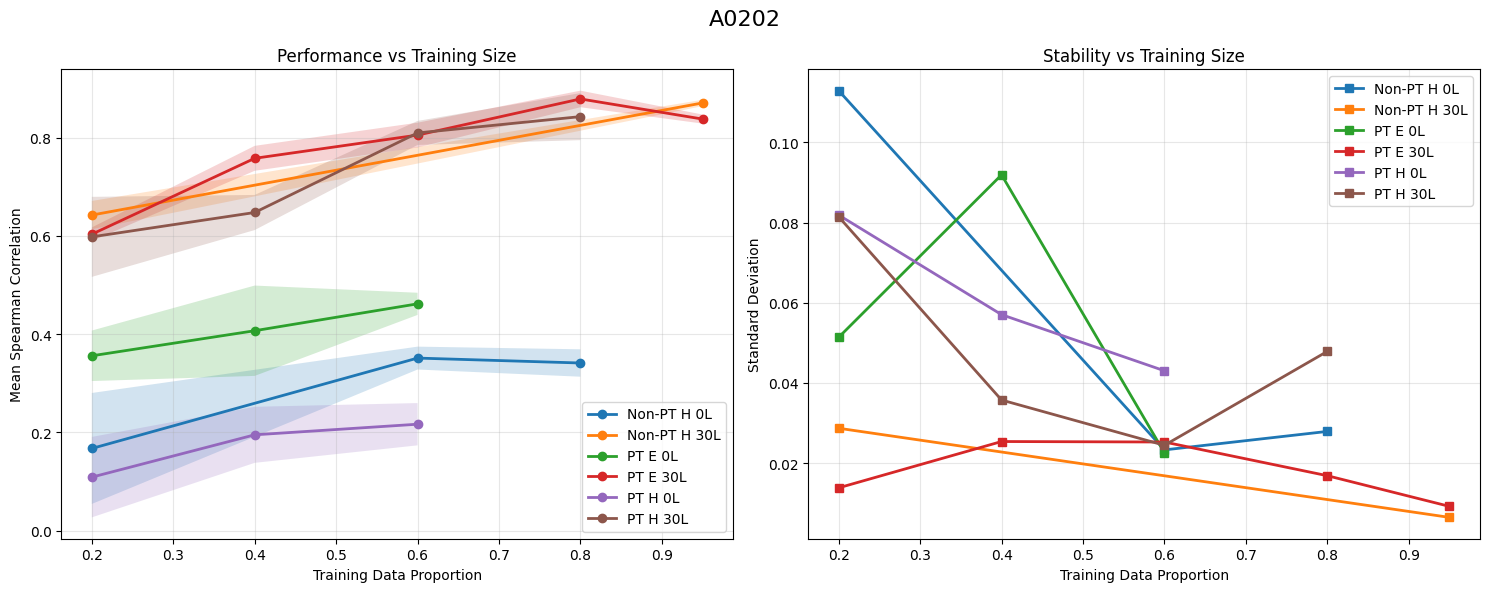

/tmp/ipykernel_3518588/3653300906.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


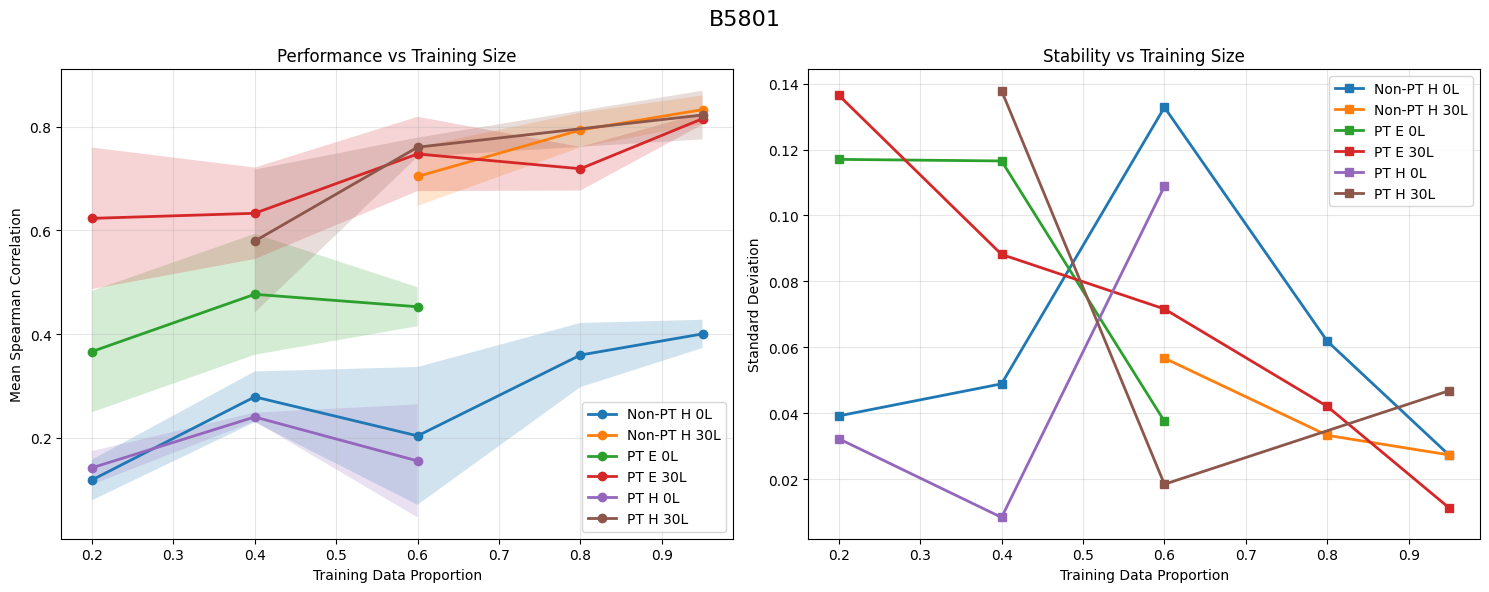

/tmp/ipykernel_3518588/3653300906.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


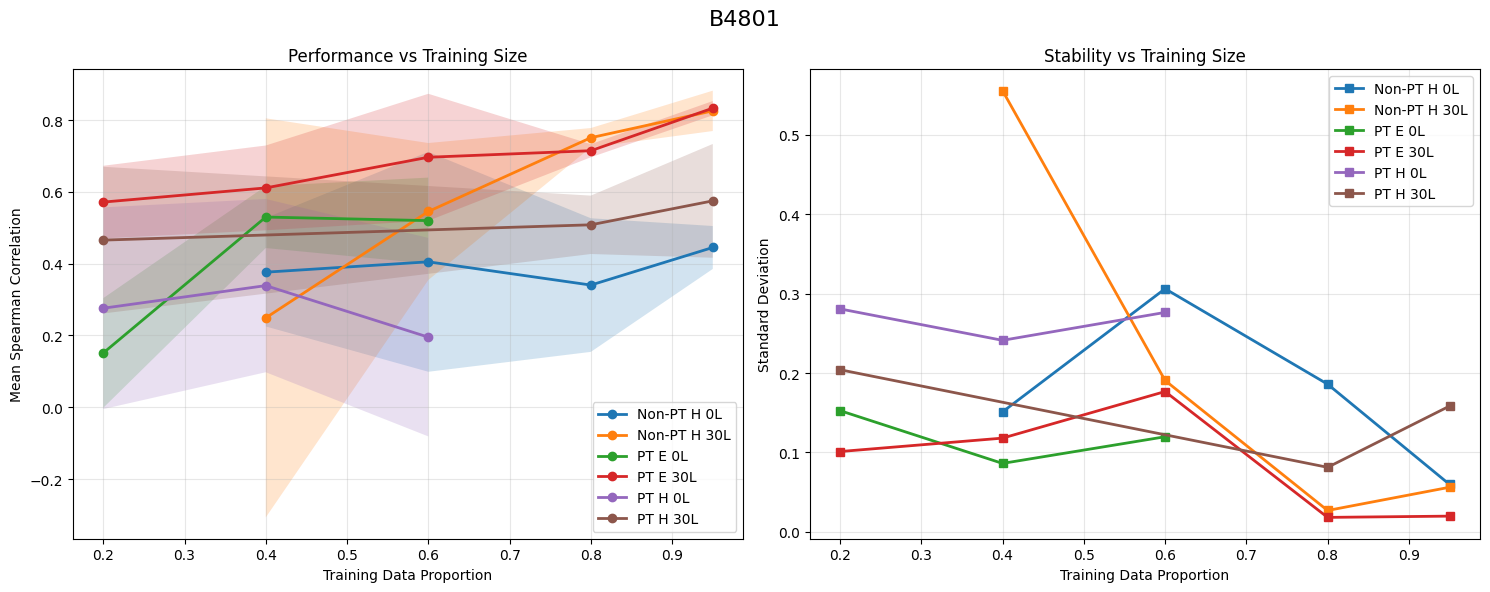

/tmp/ipykernel_3518588/3653300906.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


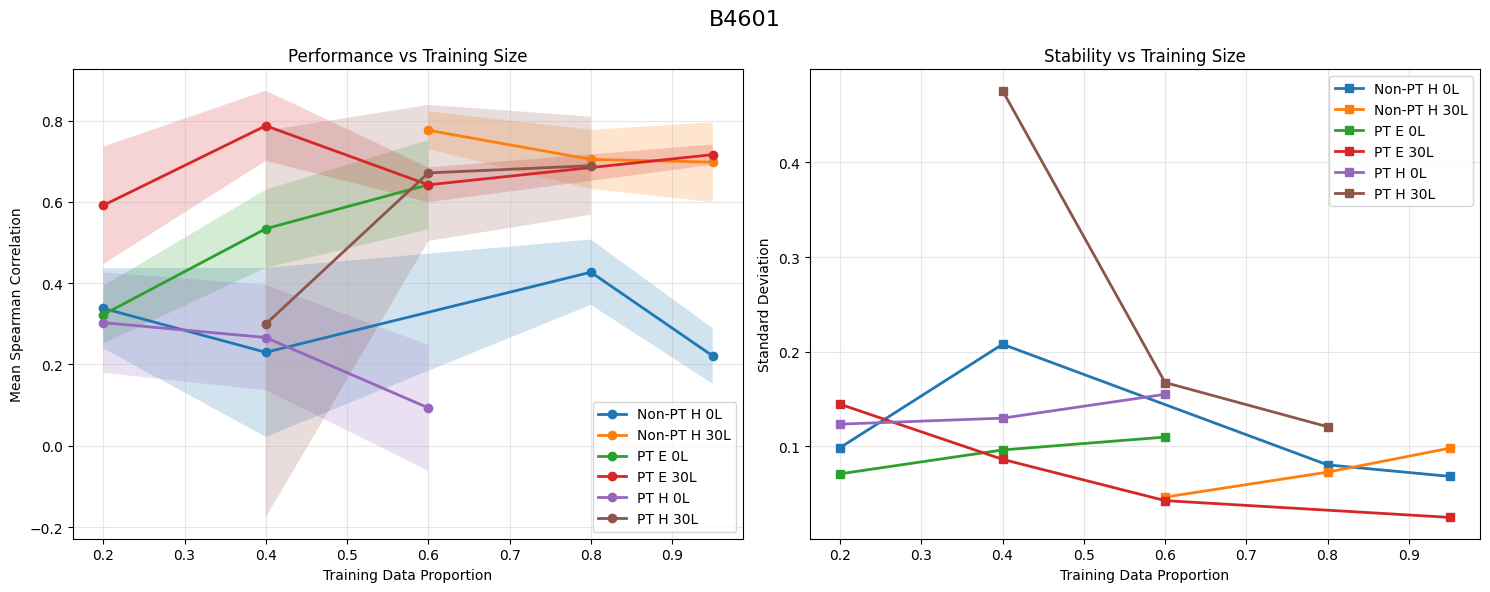

/tmp/ipykernel_3518588/3653300906.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


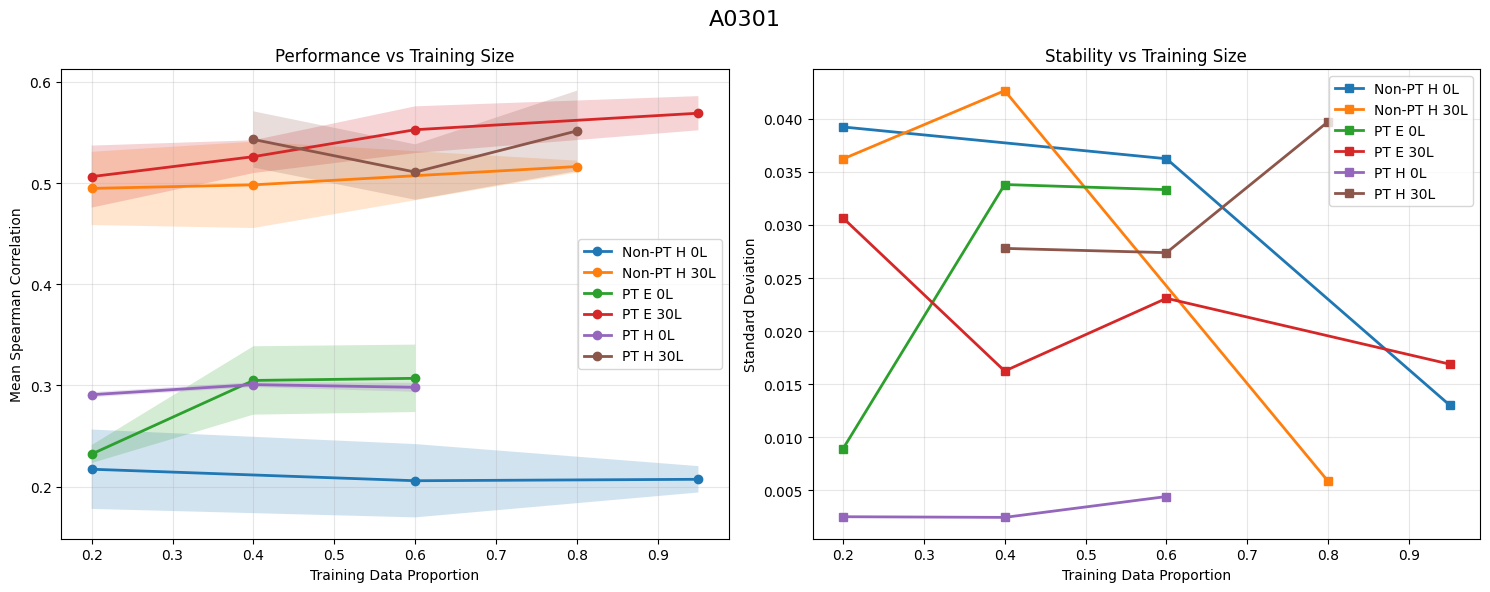

In [23]:
from scipy.stats import fligner

# === DATA PREPARATION ===
# Build replicate statistics table
rep_stats = (
    subset.groupby(['HLA', 'group_label', 'data_prop'])['spearman']
    .agg(n_reps='size', mean='mean', std='std')
    .reset_index()
)
rep_stats['std'] = rep_stats['std'].fillna(0.0)

# Helper functions
def IQR(x): 
    return x.quantile(0.75) - x.quantile(0.25)

def coerce_prop(x):
    """Convert data_prop to numeric 0-1 scale"""
    s = x.astype(str).str.rstrip('%')
    v = pd.to_numeric(s, errors='coerce')
    return v/100.0 if v.max() > 1 else v

def slope_ci(sub):
    """Calculate slope with confidence intervals"""
    x = coerce_prop(sub['data_prop'])
    y = sub['mean']
    ok = (~x.isna()) & (~y.isna())
    
    if ok.sum() < 3 or x[ok].nunique() < 3:
        return pd.Series({
            'slope': np.nan, 'lo': np.nan, 'hi': np.nan, 
            'n_points': int(ok.sum()), 'r_squared': np.nan
        })
    
    X = sm.add_constant(x[ok].values)
    fit = sm.OLS(y[ok].values, X).fit()
    lo, hi = fit.conf_int(alpha=0.05)[1]
    
    return pd.Series({
        'slope': fit.params[1], 
        'lo': lo, 
        'hi': hi, 
        'n_points': int(ok.sum()),
        'r_squared': fit.rsquared
    })

for TARGET_HLA in ['A0202','B5801','B4801', 'B4601', 'A0301']:
    # Filter data for target HLA
    hla_data = rep_stats[rep_stats['HLA'] == TARGET_HLA].copy()

    if hla_data.empty:
        print(f"No data found for HLA: {TARGET_HLA}")
        print(f"Available HLAs: {sorted(rep_stats['HLA'].unique())}")
    else:
        # === STABILITY ANALYSIS ===
        hla_regime = (
            hla_data.groupby(['group_label'])
            .agg(
                n_triples=('std', 'size'),
                median_std=('std', 'median'),
                iqr_std=('std', IQR),
                p95_std=('std', lambda s: s.quantile(0.95)),
                median_mean=('mean', 'median'),
                max_mean=('mean', 'max'),
                min_mean=('mean', 'min')
            )
            .reset_index()
        )

        # === TREND ANALYSIS ===
        slopes_hla = (
            hla_data.groupby(['group_label'])
            .apply(slope_ci)
            .reset_index()
        )
        slopes_hla['slope_sig'] = (slopes_hla['lo'] > 0) | (slopes_hla['hi'] < 0)

        # === VISUALIZATION ===
        
        # Performance vs Training Size Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'{TARGET_HLA}', fontsize=16)
        
        # Convert data_prop for plotting
        hla_data['data_prop_numeric'] = coerce_prop(hla_data['data_prop'])
        
        # Plot 1: Mean performance vs training size
        for regime in hla_data['group_label'].unique():
            regime_data = hla_data[hla_data['group_label'] == regime]
            ax1.plot(regime_data['data_prop_numeric'], regime_data['mean'], 
                    marker='o', label=regime, linewidth=2, markersize=6)
            ax1.fill_between(regime_data['data_prop_numeric'], 
                            regime_data['mean'] - regime_data['std'],
                            regime_data['mean'] + regime_data['std'],
                            alpha=0.2)
        
        ax1.set_xlabel('Training Data Proportion')
        ax1.set_ylabel('Mean Spearman Correlation')
        ax1.set_title('Performance vs Training Size')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Stability (std) vs training size
        for regime in hla_data['group_label'].unique():
            regime_data = hla_data[hla_data['group_label'] == regime]
            ax2.plot(regime_data['data_prop_numeric'], regime_data['std'], 
                    marker='s', label=regime, linewidth=2, markersize=6)
        
        ax2.set_xlabel('Training Data Proportion')
        ax2.set_ylabel('Standard Deviation')
        ax2.set_title('Stability vs Training Size')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


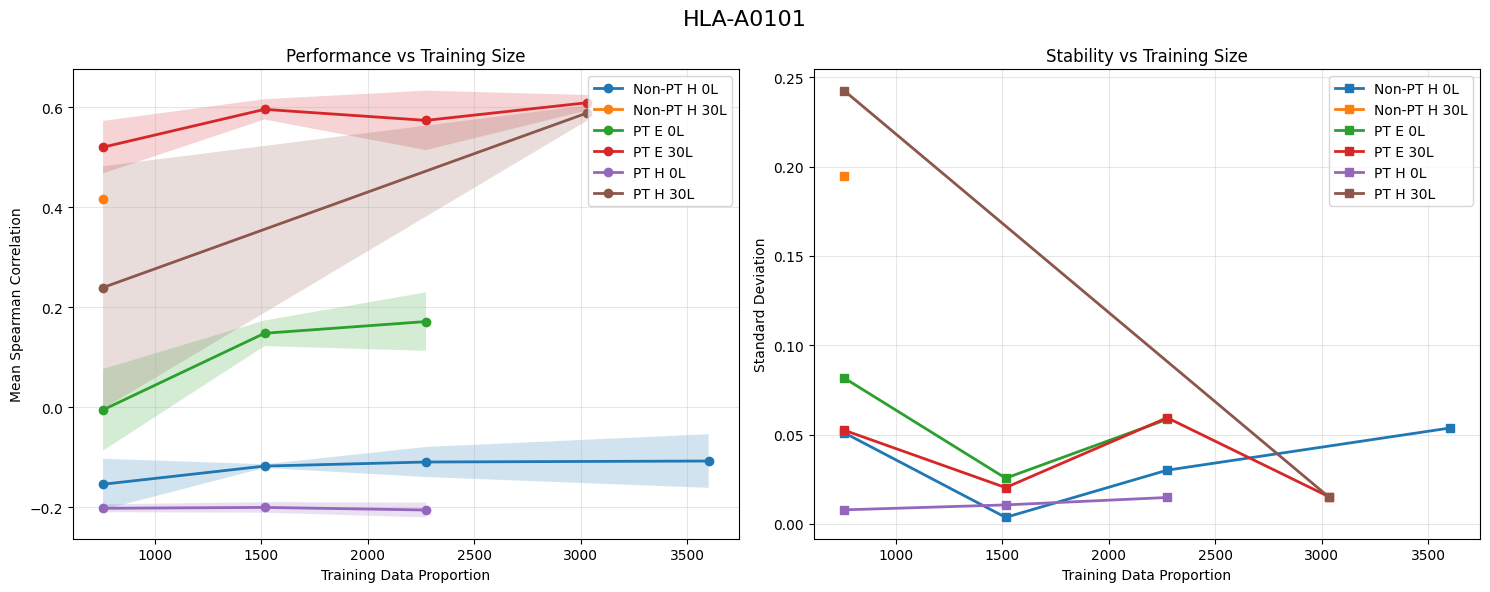

No data found for HLA: A0202
Available HLAs: ['A0101', 'A0201', 'A0205', 'A0301', 'A1101', 'A2402', 'A2601', 'A3001', 'A3101', 'A3301', 'A6801', 'B0702', 'B0801', 'B1501', 'B1801', 'B3801', 'B3901', 'B3906', 'B4402', 'B4403']


/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


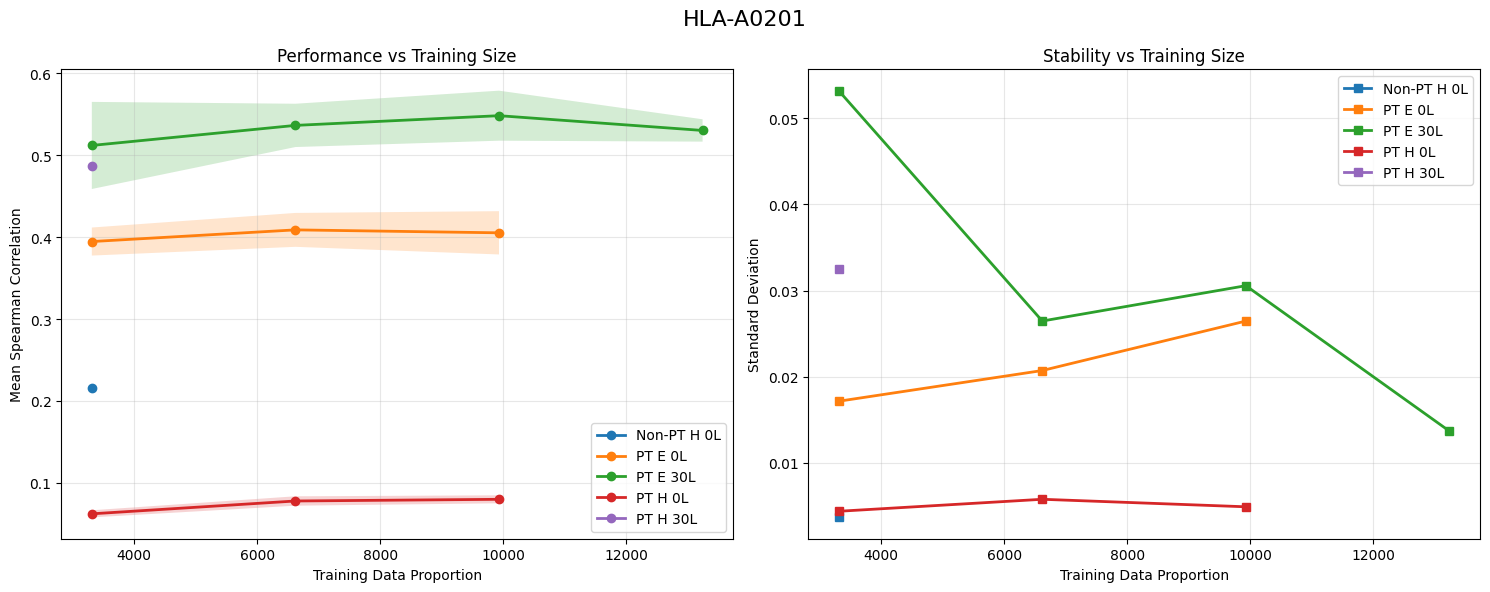

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


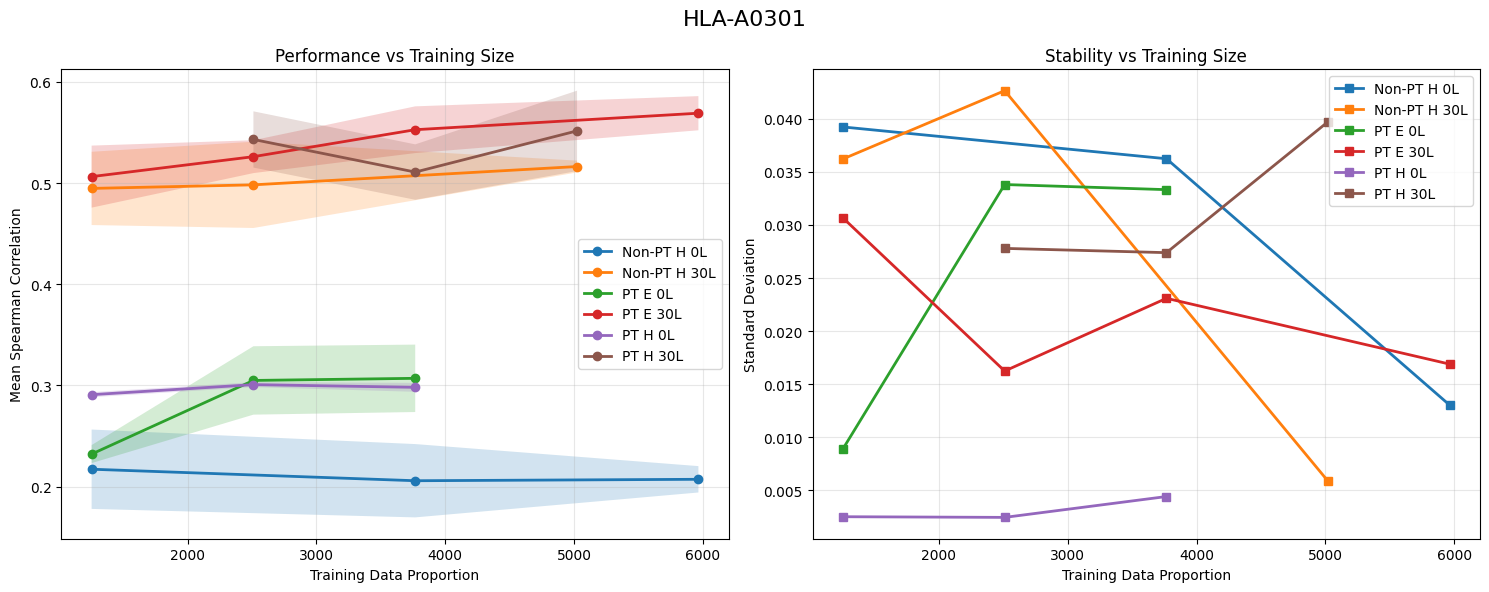

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


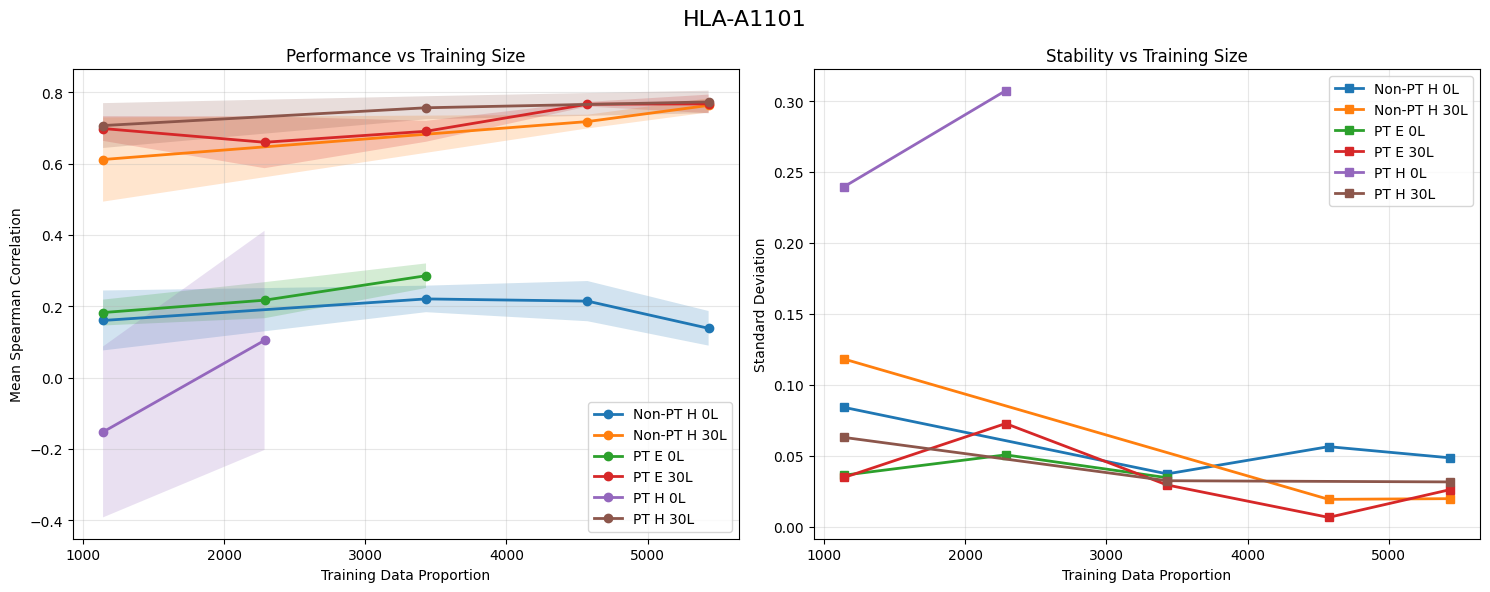

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


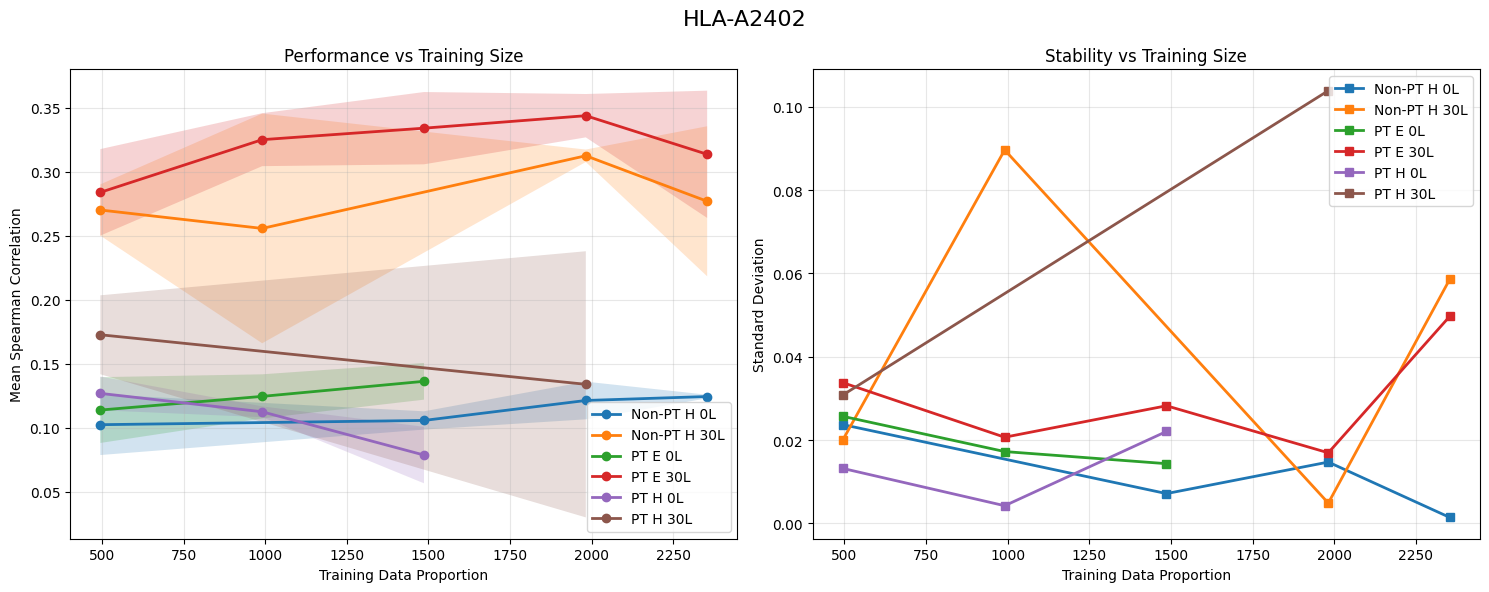

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


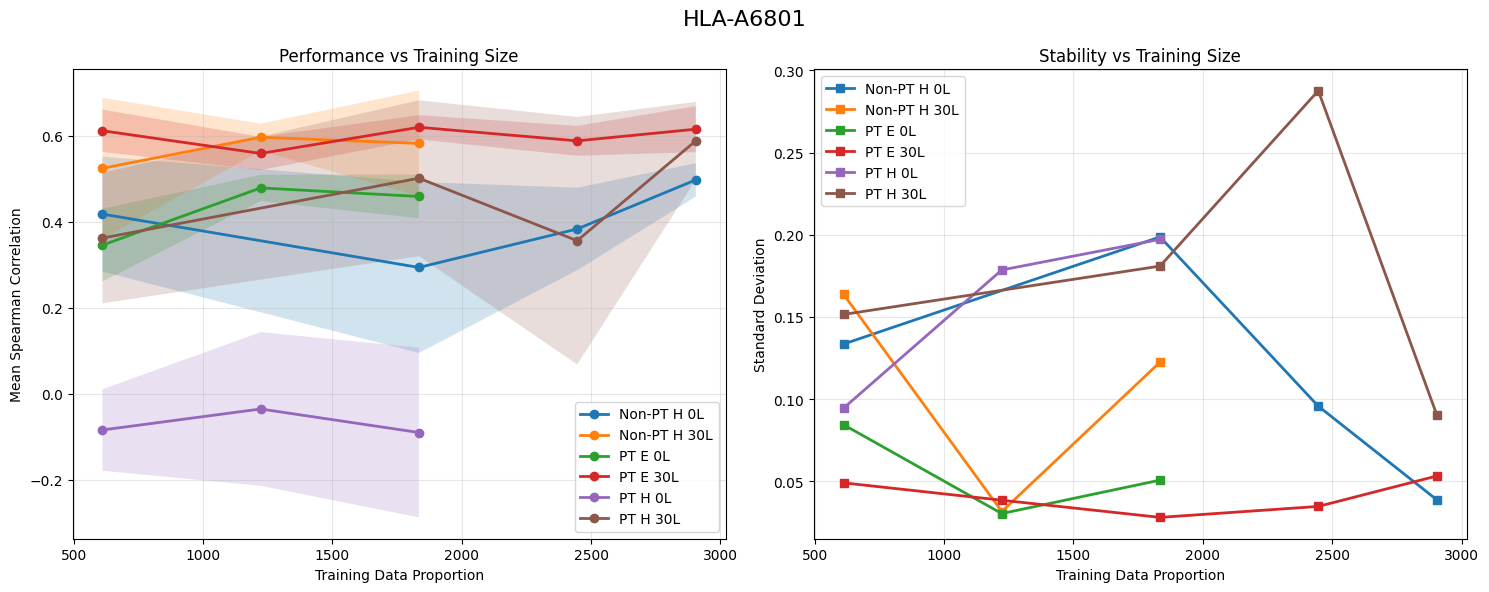

/tmp/ipykernel_3518588/1475043484.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci)


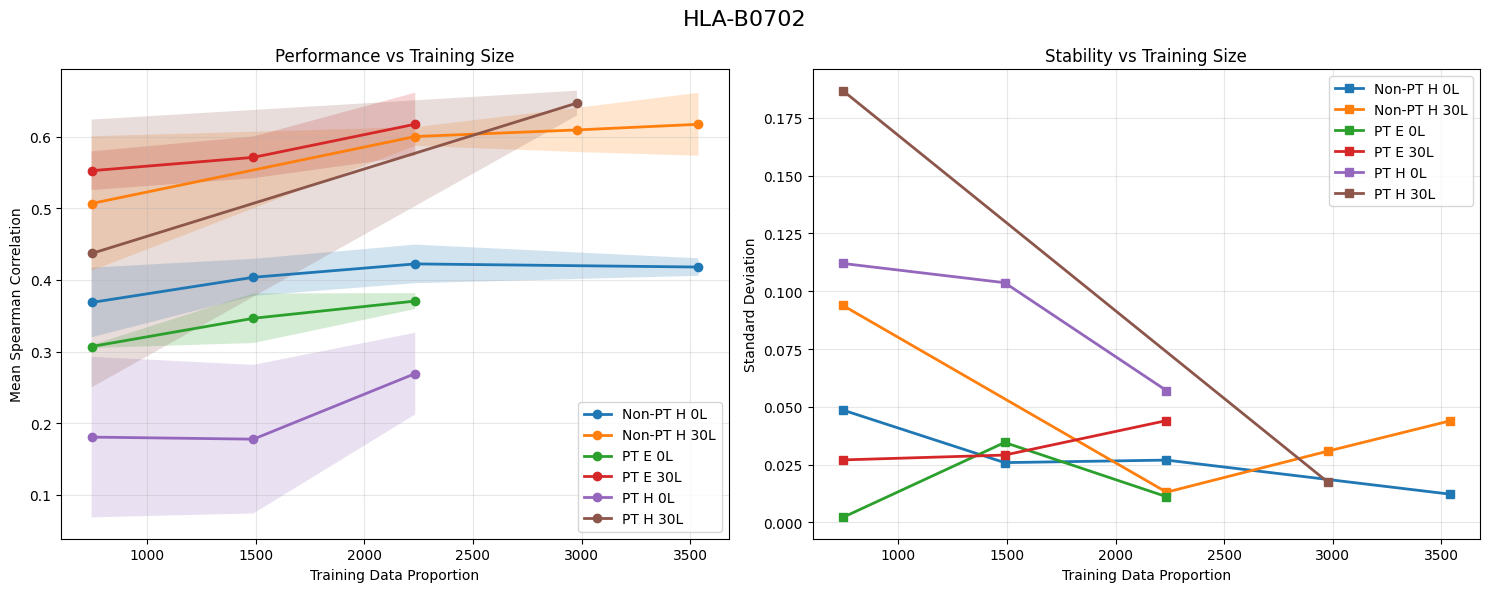

In [24]:

rep_stats = (
    subset.groupby(['HLA', 'group_label', 'training_data'])['spearman']
    .agg(n_reps='size', mean='mean', std='std')
    .reset_index()
)
rep_stats['std'] = rep_stats['std'].fillna(0.0)

# Helper functions
def IQR(x): 
    return x.quantile(0.75) - x.quantile(0.25)

def coerce_prop(x):
    """Convert training_data to numeric - keep as raw numbers if already numeric"""
    # If already numeric, return as-is
    if pd.api.types.is_numeric_dtype(x):
        return x
    
    # Otherwise convert from string/percentage format
    s = x.astype(str).str.rstrip('%')
    v = pd.to_numeric(s, errors='coerce')
    return v/100.0 if v.max() > 1 else v

def slope_ci(sub):
    """Calculate slope with confidence intervals"""
    x = coerce_prop(sub['training_data'])
    y = sub['mean']
    ok = (~x.isna()) & (~y.isna())
    
    if ok.sum() < 3 or x[ok].nunique() < 3:
        return pd.Series({
            'slope': np.nan, 'lo': np.nan, 'hi': np.nan, 
            'n_points': int(ok.sum()), 'r_squared': np.nan
        })
    
    X = sm.add_constant(x[ok].values)
    fit = sm.OLS(y[ok].values, X).fit()
    lo, hi = fit.conf_int(alpha=0.05)[1]
    
    return pd.Series({
        'slope': fit.params[1], 
        'lo': lo, 
        'hi': hi, 
        'n_points': int(ok.sum()),
        'r_squared': fit.rsquared
    })


for TARGET_HLA in ['A0101', 'A0202','A0201', 'A0301', 'A1101', 'A2402', 'A6801', 'B0702']:

    # Filter data for target HLA
    hla_data = rep_stats[rep_stats['HLA'] == TARGET_HLA].copy()

    if hla_data.empty:
        print(f"No data found for HLA: {TARGET_HLA}")
        print(f"Available HLAs: {sorted(rep_stats['HLA'].unique())}")
    else:
        # === STABILITY ANALYSIS ===
        hla_regime = (
            hla_data.groupby(['group_label'])
            .agg(
                n_triples=('std', 'size'),
                median_std=('std', 'median'),
                iqr_std=('std', IQR),
                p95_std=('std', lambda s: s.quantile(0.95)),
                median_mean=('mean', 'median'),
                max_mean=('mean', 'max'),
                min_mean=('mean', 'min')
            )
            .reset_index()
        )

        # === TREND ANALYSIS ===
        slopes_hla = (
            hla_data.groupby(['group_label'])
            .apply(slope_ci)
            .reset_index()
        )
        slopes_hla['slope_sig'] = (slopes_hla['lo'] > 0) | (slopes_hla['hi'] < 0)

        # === VISUALIZATION ===
        
        # Performance vs Training Size Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'HLA-{TARGET_HLA}', fontsize=16)
        
        # Convert training_data for plotting
        hla_data['training_data_numeric'] = coerce_prop(hla_data['training_data'])
        
        # Plot 1: Mean performance vs training size
        for regime in hla_data['group_label'].unique():
            regime_data = hla_data[hla_data['group_label'] == regime]
            ax1.plot(regime_data['training_data_numeric'], regime_data['mean'], 
                    marker='o', label=regime, linewidth=2, markersize=6)
            ax1.fill_between(regime_data['training_data_numeric'], 
                            regime_data['mean'] - regime_data['std'],
                            regime_data['mean'] + regime_data['std'],
                            alpha=0.2)
        
        ax1.set_xlabel('Training Data Proportion')
        ax1.set_ylabel('Mean Spearman Correlation')
        ax1.set_title('Performance vs Training Size')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Stability (std) vs training size
        for regime in hla_data['group_label'].unique():
            regime_data = hla_data[hla_data['group_label'] == regime]
            ax2.plot(regime_data['training_data_numeric'], regime_data['std'], 
                    marker='s', label=regime, linewidth=2, markersize=6)
        
        ax2.set_xlabel('Training Data Proportion')
        ax2.set_ylabel('Standard Deviation')
        ax2.set_title('Stability vs Training Size')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [25]:
rep_stats

,HLA,group_label,training_data,n_reps,mean,std
0,A0101,Non-PT H 0L,758.0,3,-0.153778,0.051005
1,A0101,Non-PT H 0L,1516.0,3,-0.117479,0.003636
2,A0101,Non-PT H 0L,2274.0,3,-0.109311,0.030064
3,A0101,Non-PT H 0L,3600.5,3,-0.107355,0.053646
4,A0101,Non-PT H 30L,758.0,3,0.416752,0.194719
...,...,...,...,...,...,...
236,B4402,PT E 0L,1009.8,3,0.322349,0.026918
237,B4402,PT E 30L,336.6,3,0.313455,0.072734
238,B4402,PT E 30L,673.2,4,0.428751,0.084453
239,B4402,PT E 30L,1009.8,4,0.440927,0.054675


Pooled analysis across 8 HLAs
Total data points: 130


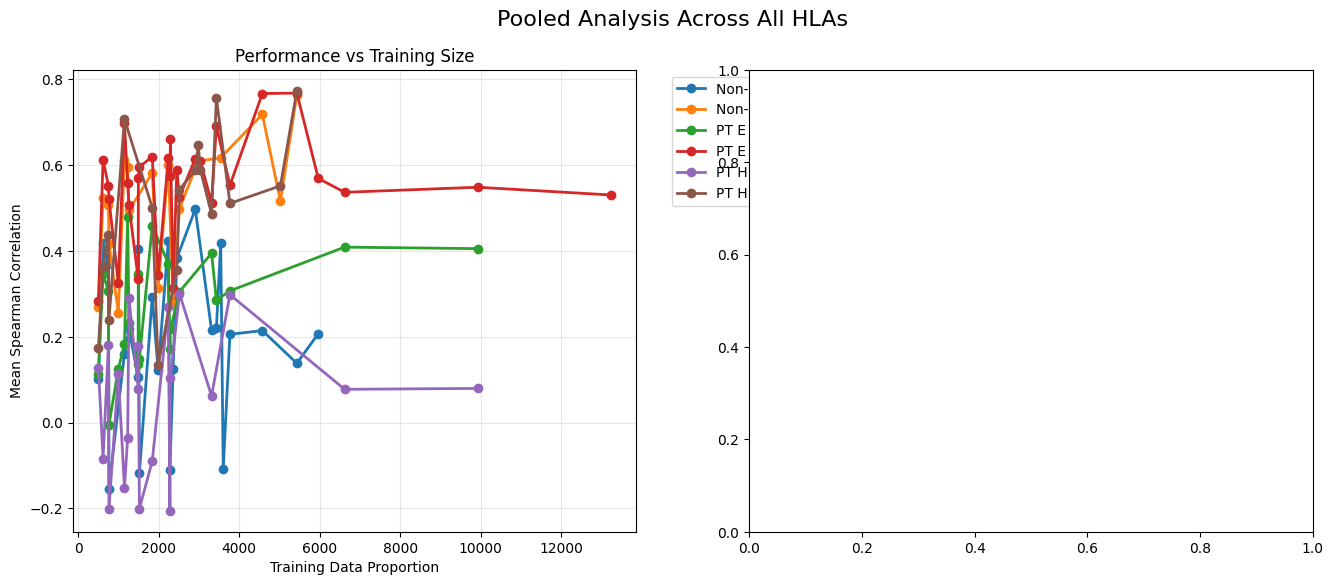

In [26]:
# === CLEAN POOLED ANALYSIS ===

# Filter for the target HLAs
target_hlas = ['A0101', 'A0202','A0201', 'A0301', 'A1101', 'A2402', 'A6801', 'B0702']
pooled_data = rep_stats[rep_stats['HLA'].isin(target_hlas)].copy()

print(f"Pooled analysis across {len(target_hlas)} HLAs")
print(f"Total data points: {len(pooled_data)}")

if not pooled_data.empty:
    # Convert training_data to numeric for all pooled data
    pooled_data['training_data_numeric'] = coerce_prop(pooled_data['training_data'])
    
    # Calculate pooled statistics by group_label and training_data
    pooled_stats = (
        pooled_data.groupby(['group_label', 'training_data_numeric'])
        .agg(
            mean_performance=('mean', 'mean'),
            std_performance=('mean', 'std'),
            mean_stability=('std', 'mean'),
            std_stability=('std', 'std'),
            n_hlas=('HLA', 'nunique'),
            n_total_reps=('n_reps', 'sum')
        )
        .reset_index()
    )
    
    # Calculate standard error of the mean
    pooled_stats['sem_performance'] = pooled_stats['std_performance'] / np.sqrt(pooled_stats['n_hlas'])
    pooled_stats['sem_stability'] = pooled_stats['std_stability'] / np.sqrt(pooled_stats['n_hlas'])
    pooled_stats['sem_performance'] = pooled_stats['sem_performance'].fillna(0)
    pooled_stats['sem_stability'] = pooled_stats['sem_stability'].fillna(0)
    
    # === SIMPLE CLEAN VISUALIZATION ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Pooled Analysis Across All HLAs', fontsize=16)
    
    # Plot 1: Performance vs Training Size
    for regime in pooled_stats['group_label'].unique():
        regime_data = pooled_stats[pooled_stats['group_label'] == regime].sort_values('training_data_numeric')
        
        # Shaded confidence interval
        ax1.fill_between(regime_data['training_data_numeric'],
                        regime_data['mean_performance'] - regime_data['sem_performance'],
                        regime_data['mean_performance'] + regime_data['sem_performance'],
                        alpha=0.2)
        
        # Main line
        ax1.plot(regime_data['training_data_numeric'], regime_data['mean_performance'],
                marker='o', label=regime, linewidth=2, markersize=6)
    
    ax1.set_xlabel('Training Data Proportion')
    ax1.set_ylabel('Mean Spearman Correlation')
    ax1.set_title('Performance vs Training Size')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # # Plot 2: Stability vs Training Size
    # for i, regime in enumerate(regimes):
    #     regime_data = pooled_stats[pooled_stats['group_label'] == regime].sort_values('training_data_numeric')
    #     color = colors[i]
        
    #     # Shaded confidence interval FIRST (behind the line)
    #     ax2.fill_between(regime_data['training_data_numeric'],
    #                     regime_data['mean_stability'] - regime_data['sem_stability'],
    #                     regime_data['mean_stability'] + regime_data['sem_stability'],
    #                     alpha=0.3, color=color)
        
    #     # Main line ON TOP
    #     ax2.plot(regime_data['training_data_numeric'], regime_data['mean_stability'],
    #             marker='o', label=regime, linewidth=2, markersize=6, color=color)
    
    # ax2.set_xlabel('Training Data Proportion')
    # ax2.set_ylabel('Standard Deviation')
    # ax2.set_title('Stability vs Training Size')
    # ax2.grid(True, alpha=0.3)
    # ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # plt.tight_layout()
    # plt.show()

else:
    print("No data available for pooled analysis")

In [27]:
rep_stats["HLA"].unique()

array(['A0101', 'A0201', 'A0205', 'A0301', 'A1101', 'A2402', 'A2601',
       'A3001', 'A3101', 'A3301', 'A6801', 'B0702', 'B0801', 'B1501',
       'B1801', 'B3801', 'B3901', 'B3906', 'B4402', 'B4403'], dtype=object)

/tmp/ipykernel_3518588/3790830286.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pooled_mean_std)
/tmp/ipykernel_3518588/3790830286.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_ci_from_group)


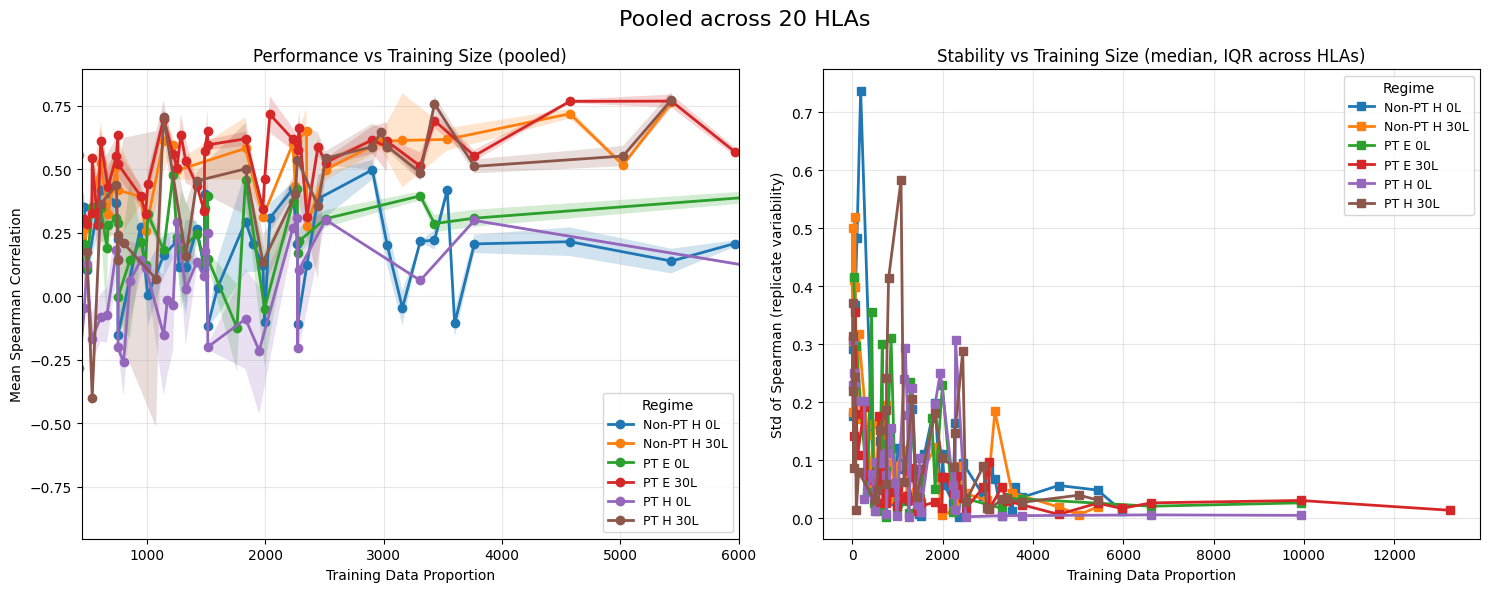

=== Pooled slopes (mean vs training proportion) ===
 group_label    slope        lo       hi  n_points  r_squared  slope_sig
    PT H 30L 0.000153  0.000106 0.000201      32.0   0.589376       True
Non-PT H 30L 0.000090  0.000051 0.000129      35.0   0.399411       True
    PT E 30L 0.000020  0.000003 0.000037      51.0   0.105657       True
     PT H 0L 0.000025 -0.000011 0.000060      41.0   0.048089      False
     PT E 0L 0.000024 -0.000001 0.000049      39.0   0.090676      False
 Non-PT H 0L 0.000017 -0.000020 0.000055      43.0   0.020763      False


In [28]:
# --- POOL ACROSS HLAs AND PLOT TOGETHER ---

# Choose which HLAs to include (change if needed)
target_hlas = rep_stats["HLA"].unique()

# Filter and coerce training proportion
pooled_data = rep_stats[rep_stats['HLA'].isin(target_hlas)].copy()
if pooled_data.empty:
    raise ValueError("No rows after filtering by target_hlas. "
                     f"Available HLAs: {sorted(rep_stats['HLA'].unique())}")

pooled_data['training_data_numeric'] = coerce_prop(pooled_data['training_data'])

# Helper to compute pooled mean/std across HLAs at each (group_label, training_data) level
def pooled_mean_std(df):
    # df contains rows at HLA level with columns: n_reps, mean, std
    n = df['n_reps'].to_numpy(dtype=float)
    m = df['mean'].to_numpy(dtype=float)
    s = df['std'].to_numpy(dtype=float)

    N = n.sum()
    if N <= 1 or len(df) == 0:
        return pd.Series({'mean': np.nan, 'std': np.nan, 'n_total': N})

    # Grand mean weighted by replicate counts
    grand_mean = np.sum(n * m) / N

    # Pooled variance across all replicates:
    # within-HLA + between-HLA components
    ss_within = np.sum((n - 1.0) * (s ** 2))
    ss_between = np.sum(n * (m - grand_mean) ** 2)

    var_total = (ss_within + ss_between) / (N - 1.0) if N > 1 else np.nan
    return pd.Series({'mean': grand_mean, 'std': np.sqrt(var_total), 'n_total': N})

# Curve stats for performance panel (pooled mean ± pooled std)
curve_stats = (
    pooled_data
    .groupby(['group_label', 'training_data_numeric'], as_index=False)
    .apply(pooled_mean_std)
    .reset_index(drop=True)
)

# Stability distribution across HLAs: median with IQR band (25–75th percentile) of per-HLA stds
stability_iqr = (
    pooled_data
    .groupby(['group_label', 'training_data_numeric'])
    .agg(
        median_std = ('std', 'median'),
        q25_std    = ('std', lambda s: s.quantile(0.25)),
        q75_std    = ('std', lambda s: s.quantile(0.75)),
        n_hlas     = ('HLA', 'nunique')
    )
    .reset_index()
)

# Optional: slope and CI on the pooled means per regime
def slope_ci_from_group(g):
    # Reuse your slope_ci by matching expected column names
    sub = pd.DataFrame({
        'training_data': g['training_data_numeric'].values,
        'mean': g['mean'].values
    })
    return slope_ci(sub)

slopes_pooled = (
    curve_stats
    .dropna(subset=['training_data_numeric', 'mean'])
    .groupby('group_label')
    .apply(slope_ci_from_group)
    .reset_index()
)
slopes_pooled['slope_sig'] = (slopes_pooled['lo'] > 0) | (slopes_pooled['hi'] < 0)

# ====== PLOTTING ======
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Pooled across {pooled_data['HLA'].nunique()} HLAs", fontsize=16)

# Plot 1: POOLED mean performance vs training size with pooled error bands
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['training_data_numeric']).sort_values('training_data_numeric')
    if g.empty:
        continue
    ax1.plot(g['training_data_numeric'], g['mean'], marker='o', linewidth=2, markersize=6, label=regime)
    # mean ± pooled std
    ylo = g['mean'] - g['std']
    yhi = g['mean'] + g['std']
    ax1.fill_between(g['training_data_numeric'], ylo, yhi, alpha=0.20)

ax1.set_xlabel('Training Data Proportion')
ax1.set_ylabel('Mean Spearman Correlation')
ax1.set_title('Performance vs Training Size (pooled)')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Regime', fontsize=9)
ax1.set_xlim([450, 6000])

# Plot 2: STABILITY median std vs training size with IQR bands across HLAs
for regime, g in stability_iqr.groupby('group_label'):
    g = g.dropna(subset=['training_data_numeric']).sort_values('training_data_numeric')
    if g.empty:
        continue
    ax2.plot(g['training_data_numeric'], g['median_std'], marker='s', linewidth=2, markersize=6, label=regime)
    ax2.fill_between(g['training_data_numeric'], g['q25_std'], g['q75_std'], alpha=0.20)

ax2.set_xlabel('Training Data Proportion')
ax2.set_ylabel('Std of Spearman (replicate variability)')
ax2.set_title('Stability vs Training Size (median, IQR across HLAs)')
ax2.grid(True, alpha=0.3)
ax2.legend(title='Regime', fontsize=9)

plt.tight_layout()
plt.show()

# (Optional) quick glance at slopes on pooled curves
print("=== Pooled slopes (mean vs training proportion) ===")
print(slopes_pooled.sort_values(['slope_sig','slope'], ascending=[False, False])
      .to_string(index=False))


In [29]:
rep_stats

,HLA,group_label,training_data,n_reps,mean,std
0,A0101,Non-PT H 0L,758.0,3,-0.153778,0.051005
1,A0101,Non-PT H 0L,1516.0,3,-0.117479,0.003636
2,A0101,Non-PT H 0L,2274.0,3,-0.109311,0.030064
3,A0101,Non-PT H 0L,3600.5,3,-0.107355,0.053646
4,A0101,Non-PT H 30L,758.0,3,0.416752,0.194719
...,...,...,...,...,...,...
236,B4402,PT E 0L,1009.8,3,0.322349,0.026918
237,B4402,PT E 30L,336.6,3,0.313455,0.072734
238,B4402,PT E 30L,673.2,4,0.428751,0.084453
239,B4402,PT E 30L,1009.8,4,0.440927,0.054675


In [30]:
rep_stats

,HLA,group_label,training_data,n_reps,mean,std
0,A0101,Non-PT H 0L,758.0,3,-0.153778,0.051005
1,A0101,Non-PT H 0L,1516.0,3,-0.117479,0.003636
2,A0101,Non-PT H 0L,2274.0,3,-0.109311,0.030064
3,A0101,Non-PT H 0L,3600.5,3,-0.107355,0.053646
4,A0101,Non-PT H 30L,758.0,3,0.416752,0.194719
...,...,...,...,...,...,...
236,B4402,PT E 0L,1009.8,3,0.322349,0.026918
237,B4402,PT E 30L,336.6,3,0.313455,0.072734
238,B4402,PT E 30L,673.2,4,0.428751,0.084453
239,B4402,PT E 30L,1009.8,4,0.440927,0.054675


In [31]:
mask = evaluations_dt_plot['group_label'].str.contains('Non-PT E', na=False) \
       & evaluations_dt_plot['training_data'].notna()

out = (evaluations_dt_plot.loc[mask]
         .groupby(['group_label', 'training_data'])['spearman']
         .mean()
         .rename('mean')            # let “mean” be spearman
         .reset_index())

out['HLA'] = 'pooled'
out = out[['group_label', 'training_data', 'mean', 'HLA']]
out['std'] = 0
out['n_reps'] = 3
out = out[['HLA','group_label', 'training_data', 'n_reps','mean','std']]
out

,HLA,group_label,training_data,n_reps,mean,std
0,pooled,Non-PT E 0L,3.6,3,0.000000,0
1,pooled,Non-PT E 0L,6.6,3,0.185695,0
2,pooled,Non-PT E 0L,7.2,3,0.000000,0
3,pooled,Non-PT E 0L,10.8,3,0.000000,0
4,pooled,Non-PT E 0L,13.2,3,0.467676,0
...,...,...,...,...,...,...
285,pooled,Non-PT E 30L,6290.9,3,0.000000,0
286,pooled,Non-PT E 30L,6620.0,3,0.505409,0
287,pooled,Non-PT E 30L,9930.0,3,0.536212,0
288,pooled,Non-PT E 30L,13240.0,3,0.523697,0


In [32]:
rep_stats_pooled = pd.concat([rep_stats, out])
rep_stats_pooled = rep_stats_pooled[rep_stats_pooled['training_data'] < 7000]

In [40]:
rep_stats[rep_stats['training_data'] > 3500]

,HLA,group_label,training_data,n_reps,mean,std
3,A0101,Non-PT H 0L,3600.50,3,-0.107355,0.053646
19,A0201,PT E 0L,6620.00,4,0.408913,0.020703
20,A0201,PT E 0L,9930.00,3,0.405315,0.026453
22,A0201,PT E 30L,6620.00,3,0.536583,0.026454
23,A0201,PT E 30L,9930.00,4,0.548446,0.030560
24,A0201,PT E 30L,13240.00,3,0.530392,0.013658
26,A0201,PT H 0L,6620.00,3,0.077638,0.005742
27,A0201,PT H 0L,9930.00,3,0.079687,0.004869
33,A0301,Non-PT H 0L,3766.80,3,0.205749,0.036235
34,A0301,Non-PT H 0L,5964.10,3,0.207164,0.013032


In [33]:
rep_stats_pooled.to_csv('../../data/regimes.csv', index=False)

/tmp/ipykernel_3518588/1656452755.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pooled_data
/tmp/ipykernel_3518588/1656452755.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pooled_mean_std)
/tmp/ipykernel_3518588/1656452755.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['group_label',

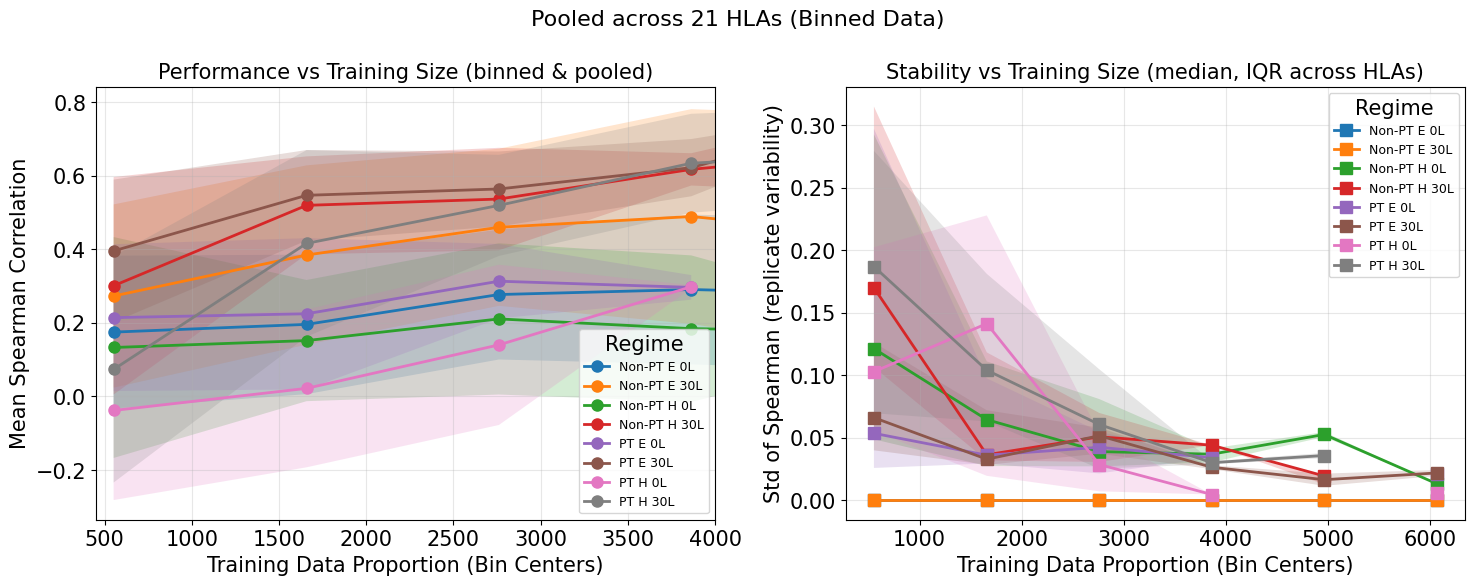

In [34]:
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 15,
})
# --- POOL ACROSS HLAs AND PLOT TOGETHER (WITH BINNING) ---

# Choose which HLAs to include (change if needed)
target_hlas = rep_stats_pooled["HLA"].unique()

# Filter and coerce training proportion
pooled_data = rep_stats_pooled[rep_stats_pooled['HLA'].isin(target_hlas)].copy()
if pooled_data.empty:
    raise ValueError("No rows after filtering by target_hlas. "
                     f"Available HLAs: {sorted(rep_stats_pooled['HLA'].unique())}")

pooled_data['training_data_numeric'] = coerce_prop(pooled_data['training_data'])

# ====== ADD BINNING LOGIC ======
def create_bins(data, n_bins=10, method='equal_width'):
    """
    Create bins for training data proportion.
    
    Args:
        data: Series of training_data_numeric values
        n_bins: Number of bins to create
        method: 'equal_width' or 'equal_count' (quantile-based)
    """
    if method == 'equal_width':
        # Equal-width bins
        bins = pd.cut(data, bins=n_bins, include_lowest=True)
        # Get bin centers for plotting
        bin_centers = bins.apply(lambda x: x.mid if pd.notna(x) else np.nan)
    elif method == 'equal_count':
        # Equal-count bins (quantile-based)
        bins = pd.qcut(data, q=n_bins, duplicates='drop')
        bin_centers = bins.apply(lambda x: x.mid if pd.notna(x) else np.nan)
    else:
        raise ValueError("method must be 'equal_width' or 'equal_count'")
    
    return bins, bin_centers

# Create bins - you can adjust n_bins and method as needed
pooled_data['training_bin'], pooled_data['bin_center'] = create_bins(
    pooled_data['training_data_numeric'], 
    n_bins=6,  # Adjust this number as needed
    method='equal_width'  # or 'equal_count'
)

# Helper to compute pooled mean/std across HLAs at each (group_label, bin) level
def pooled_mean_std(df):
    # df contains rows at HLA level with columns: n_reps, mean, std
    n = df['n_reps'].to_numpy(dtype=float)
    m = df['mean'].to_numpy(dtype=float)
    s = df['std'].to_numpy(dtype=float)

    N = n.sum()
    if N <= 1 or len(df) == 0:
        return pd.Series({'mean': np.nan, 'std': np.nan, 'n_total': N})

    # Grand mean weighted by replicate counts
    grand_mean = np.sum(n * m) / N

    # Pooled variance across all replicates:
    # within-HLA + between-HLA components
    ss_within = np.sum((n - 1.0) * (s ** 2))
    ss_between = np.sum(n * (m - grand_mean) ** 2)

    var_total = (ss_within + ss_between) / (N - 1.0) if N > 1 else np.nan
    return pd.Series({'mean': grand_mean, 'std': np.sqrt(var_total), 'n_total': N})

# Curve stats for performance panel (pooled mean ± pooled std) - NOW USING BINS
curve_stats = (
    pooled_data
    .groupby(['group_label', 'bin_center'], as_index=False)
    .apply(pooled_mean_std)
    .reset_index(drop=True)
)

# Stability distribution across HLAs: median with IQR band (25–75th percentile) of per-HLA stds
stability_iqr = (
    pooled_data
    .groupby(['group_label', 'bin_center'])
    .agg(
        median_std = ('std', 'median'),
        q25_std    = ('std', lambda s: s.quantile(0.25)),
        q75_std    = ('std', lambda s: s.quantile(0.75)),
        n_hlas     = ('HLA', 'nunique'),
        n_points   = ('HLA', 'count')  # Number of original data points in this bin
    )
    .reset_index()
)

# Optional: slope and CI on the pooled means per regime (using binned data)
def slope_ci_from_group(g):
    # Reuse your slope_ci by matching expected column names
    sub = pd.DataFrame({
        'training_data': g['bin_center'].values,
        'mean': g['mean'].values
    })
    return slope_ci(sub)

slopes_pooled = (
    curve_stats
    .dropna(subset=['bin_center', 'mean'])
    .groupby('group_label')
    .apply(slope_ci_from_group)
    .reset_index()
)
slopes_pooled['slope_sig'] = (slopes_pooled['lo'] > 0) | (slopes_pooled['hi'] < 0)

# ====== PLOTTING ======
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Pooled across {pooled_data['HLA'].nunique()} HLAs (Binned Data)", fontsize=16)

# Plot 1: POOLED mean performance vs training size with pooled error bands
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['bin_center']).sort_values('bin_center')
    if g.empty:
        continue
    ax1.plot(g['bin_center'], g['mean'], marker='o', linewidth=2, markersize=8, label=regime)
    # mean ± pooled std
    ylo = g['mean'] - g['std']
    yhi = g['mean'] + g['std']
    ax1.fill_between(g['bin_center'], ylo, yhi, alpha=0.20)

ax1.set_xlabel('Training Data Proportion (Bin Centers)')
ax1.set_ylabel('Mean Spearman Correlation')
ax1.set_title('Performance vs Training Size (binned & pooled)')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Regime', fontsize=9)
ax1.set_xlim([450, 4000])

# Plot 2: STABILITY median std vs training size with IQR bands across HLAs
for regime, g in stability_iqr.groupby('group_label'):
    g = g.dropna(subset=['bin_center']).sort_values('bin_center')
    if g.empty:
        continue
    ax2.plot(g['bin_center'], g['median_std'], marker='s', linewidth=2, markersize=8, label=regime)
    ax2.fill_between(g['bin_center'], g['q25_std'], g['q75_std'], alpha=0.20)

ax2.set_xlabel('Training Data Proportion (Bin Centers)')
ax2.set_ylabel('Std of Spearman (replicate variability)')
ax2.set_title('Stability vs Training Size (median, IQR across HLAs)')
ax2.grid(True, alpha=0.3)
ax2.legend(title='Regime', fontsize=9)
# ax2.set_xlim([450, 5000])

plt.tight_layout()

# plt.savefig('../../figures/MLCB_poster.pdf')
# plt.show()

# # Print bin summary
# print("=== Bin Summary ===")
# bin_summary = (
#     pooled_data
#     .groupby(['training_bin'])
#     .agg(
#         min_val=('training_data_numeric', 'min'),
#         max_val=('training_data_numeric', 'max'),
#         center=('bin_center', 'first'),
#         count=('training_data_numeric', 'count')
#     )
#     .reset_index()
# )
# print(bin_summary.to_string(index=False))

# # (Optional) quick glance at slopes on pooled curves
# print("\n=== Pooled slopes (mean vs training proportion, binned) ===")
# print(slopes_pooled.sort_values(['slope_sig','slope'], ascending=[False, False])
#       .to_string(index=False))

In [35]:
pooled_data

,HLA,group_label,training_data,n_reps,mean,std,training_data_numeric,training_bin,bin_center
0,A0101,Non-PT H 0L,758.00,3,-0.153778,0.051005,758.00,"(-3.017, 1106.333]",551.6580
1,A0101,Non-PT H 0L,1516.00,3,-0.117479,0.003636,1516.00,"(1106.333, 2209.067]",1657.7000
2,A0101,Non-PT H 0L,2274.00,3,-0.109311,0.030064,2274.00,"(2209.067, 3311.8]",2760.4335
3,A0101,Non-PT H 0L,3600.50,3,-0.107355,0.053646,3600.50,"(3311.8, 4414.533]",3863.1665
4,A0101,Non-PT H 30L,758.00,3,0.416752,0.194719,758.00,"(-3.017, 1106.333]",551.6580
...,...,...,...,...,...,...,...,...,...
282,pooled,Non-PT E 30L,5431.15,3,0.736420,0.000000,5431.15,"(4414.533, 5517.267]",4965.9000
283,pooled,Non-PT E 30L,5610.70,3,0.000000,0.000000,5610.70,"(5517.267, 6620.0]",6068.6335
284,pooled,Non-PT E 30L,5964.10,3,0.555266,0.000000,5964.10,"(5517.267, 6620.0]",6068.6335
285,pooled,Non-PT E 30L,6290.90,3,0.000000,0.000000,6290.90,"(5517.267, 6620.0]",6068.6335


/tmp/ipykernel_3518588/1130893977.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pooled_data
/tmp/ipykernel_3518588/1130893977.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pooled_mean_std)
/tmp/ipykernel_3518588/1130893977.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['group_label',

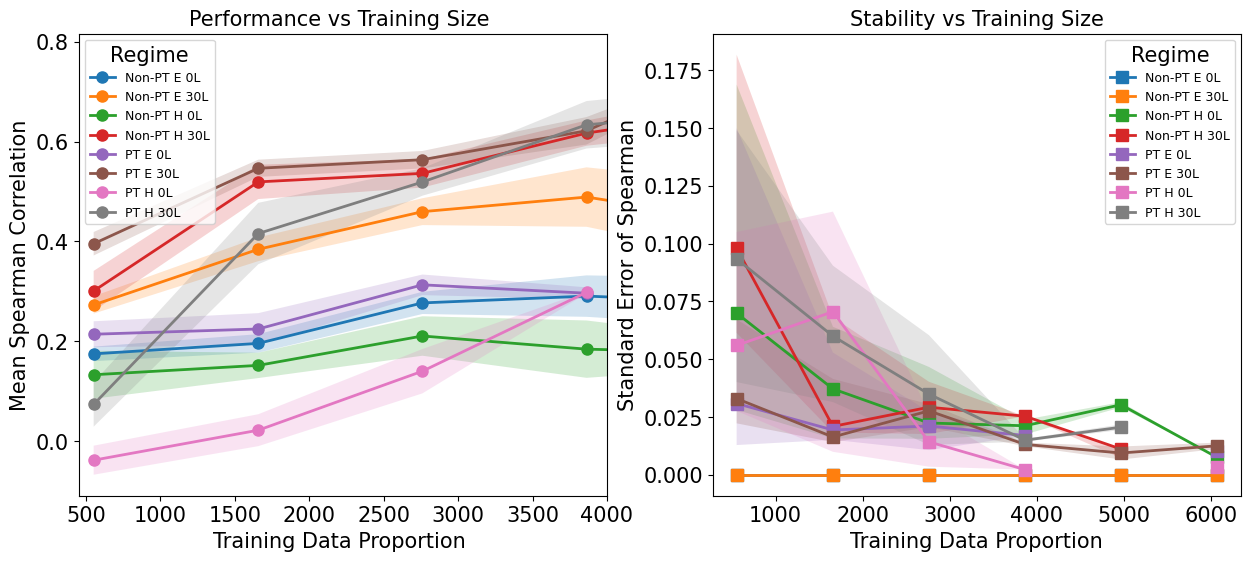

In [36]:
# --- helper now returns mean, std, se, n_total ---
def pooled_mean_std(df):
    n = df['n_reps'].to_numpy(dtype=float)
    m = df['mean'].to_numpy(dtype=float)
    s = df['std'].to_numpy(dtype=float)

    N = n.sum()
    if N <= 1 or len(df) == 0:
        return pd.Series({'mean': np.nan, 'std': np.nan, 'se': np.nan, 'n_total': N})

    grand_mean = np.sum(n * m) / N
    ss_within  = np.sum((n - 1.0) * (s ** 2))
    ss_between = np.sum(n * (m - grand_mean) ** 2)
    var_total  = (ss_within + ss_between) / (N - 1.0) if N > 1 else np.nan
    std_total  = np.sqrt(var_total)
    se_total   = std_total / np.sqrt(N)  # <-- Standard Error

    return pd.Series({'mean': grand_mean, 'std': std_total, 'se': se_total, 'n_total': N})

# Compute per-row SE to aggregate stability as SE instead of SD
pooled_data['se'] = pooled_data['std'] / np.sqrt(pooled_data['n_reps'].astype(float))

# ===== curve stats stay the same call but now include 'se' =====
curve_stats = (
    pooled_data
    .groupby(['group_label', 'bin_center'], as_index=False)
    .apply(pooled_mean_std)
    .reset_index(drop=True)
)

# ===== stability panel now aggregates SE across HLAs (median with IQR) =====
stability_iqr = (
    pooled_data
    .groupby(['group_label', 'bin_center'])
    .agg(
        median_se = ('se', 'median'),
        q25_se    = ('se', lambda s: s.quantile(0.25)),
        q75_se    = ('se', lambda s: s.quantile(0.75)),
        n_hlas    = ('HLA', 'nunique'),
        n_points  = ('HLA', 'count')
    )
    .reset_index()
)

# ====== PLOTTING ======
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# fig.suptitle(f"Pooled across {pooled_data['HLA'].nunique()} HLAs", fontsize=16)

# Plot 1: mean ± SE
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['bin_center']).sort_values('bin_center')
    if g.empty:
        continue
    ax1.plot(g['bin_center'], g['mean'], marker='o', linewidth=2, markersize=8, label=regime)
    ylo = g['mean'] - g['se']     # <-- SE band
    yhi = g['mean'] + g['se']
    ax1.fill_between(g['bin_center'], ylo, yhi, alpha=0.20)

ax1.set_xlabel('Training Data Proportion ')
ax1.set_ylabel('Mean Spearman Correlation')
ax1.set_title('Performance vs Training Size ')
ax1.grid(False)
ax1.legend(title='Regime', fontsize=9)
ax1.set_xlim([450, 4000])

# Plot 2: median SE with IQR
for regime, g in stability_iqr.groupby('group_label'):
    g = g.dropna(subset=['bin_center']).sort_values('bin_center')
    if g.empty:
        continue
    ax2.plot(g['bin_center'], g['median_se'], marker='s', linewidth=2, markersize=8, label=regime)
    ax2.fill_between(g['bin_center'], g['q25_se'], g['q75_se'], alpha=0.20)

ax2.set_xlabel('Training Data Proportion')
ax2.set_ylabel('Standard Error of Spearman')
ax2.set_title('Stability vs Training Size')
ax2.grid(False)
ax2.legend(title='Regime', fontsize=9)

plt.savefig('../../figures_manuscript/4a_regimes.pdf', dpi=300, bbox_inches="tight")
